#Lead Analysis for ATR Kinase Inhibitors

## Reference:
- https://patents.google.com/patent/US9340546B2/en
- https://www.nature.com/articles/s41416-023-02436-2
- https://pubmed.ncbi.nlm.nih.gov/38407317/

## Pipeline:
### 1. Dataset Overview
- Data quality
- Structure and naming consistency

### 2. Data distribution
- Potency distribution
- Toxicity distribution
- Log transformation of toxicity values

### 3. Data correlation and relationships
- Toxicity correlation
- Define a composite toxicity score (CTS)
- Potency-Toxicity correlation
- Clinical and non-clinical benchmarks

### 4. Chemical Space Exploration
- Hierarchical clustering based on Tanimoto Similarity
- MCS Analysis
- Bemis–Murcko Scaffolds

### 5. SAR Analysis for Representative Scaffolds
- MMP Analysis for Scaffolds 47, 9, and 1.

### 6. R Group Analysis
- Active Compound MMP Analysis
- All Compound SAR Analysis
- All Compound STR Analysis

### 6. Lead Prioritization Framework
- Conclusions/recommendations

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df_raw = pd.read_csv('/content/drive/MyDrive/Axiom/data/raw/full gartisertib leads.csv')
df = df_raw.copy()

## 1. Dataset Overview

**Analysis framing:** This notebook distinguishes early bioactivity (LD20) from stronger cellular injury (LD50). LD20 is the primary toxicity-margin layer for alignment with the Axiom MOS framework; LD50 is retained as a secondary layer.


In [4]:
df.describe(include="all")

,name,smiles,atr_binding_potency,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,...,er_stress_ld20,er_stress_ld50,cytoplasm_area_ld20,cytoplasm_area_ld50,bioactivity1_ld20,bioactivity1_ld50,ros_ld20,ros_ld50,halos_ld20,halos_ld50
count,553,553,553,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,...,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000
unique,553,553,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Compound_I-N-114,CN1CCN2CCN(CC2C1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=...,Inactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,23.492081,216.525658,3.012499,290.221940,2175.647180,5882.717132,117.663627,...,5.827142,50.453555,59.417781,1017.644292,2.894601,140.542556,62.792885,1470.628555,32.935772,257.628124
std,NaN,NaN,NaN,16.232288,466.906871,2.855050,1464.654993,3461.853413,4341.724316,605.592995,...,5.559683,56.101516,425.719089,2288.146140,2.991922,947.012577,483.846387,2372.078240,424.985710,1092.802959
min,NaN,NaN,NaN,4.643262,27.132564,0.672593,3.408005,12.946300,109.987564,5.127331,...,1.016840,4.191328,4.400932,26.537775,0.193626,2.323446,2.547933,17.581902,0.849593,4.597721
25%,NaN,NaN,NaN,11.671355,87.381689,1.265089,12.658842,57.118231,916.610170,18.210605,...,2.254368,15.818007,13.310692,121.950030,0.933047,12.387573,6.416086,89.578299,4.752010,23.623700
50%,NaN,NaN,NaN,19.117532,153.979574,2.090933,28.584744,245.764314,8779.213994,36.120750,...,3.825061,34.789569,24.523541,303.016587,1.870591,28.274488,11.867974,235.308557,9.336795,46.874264
75%,NaN,NaN,NaN,30.497413,241.888805,3.583990,65.409810,2451.253024,10000.000000,109.357562,...,7.775476,64.811993,55.635441,607.985185,3.534620,54.368585,55.457494,1928.041286,20.602815,123.968088


In [5]:
df.dtypes

,0
name,object
smiles,object
atr_binding_potency,object
cell_viability_ld20,float64
cell_viability_ld50,float64
bioactivity2_ld20,float64
bioactivity2_ld50,float64
ldh_ld20,float64
ldh_ld50,float64
cell_death_ld20,float64


### 1.1 Data quality

In [6]:
# Check for missing values
print("number of missing values:\n", df.isnull().sum())

number of missing values:
 name                   0
smiles                 0
atr_binding_potency    0
cell_viability_ld20    0
cell_viability_ld50    0
bioactivity2_ld20      0
bioactivity2_ld50      0
ldh_ld20               0
ldh_ld50               0
cell_death_ld20        0
cell_death_ld50        0
nuclei_size_ld20       0
nuclei_size_ld50       0
mitochondria_ld20      0
mitochondria_ld50      0
er_stress_ld20         0
er_stress_ld50         0
cytoplasm_area_ld20    0
cytoplasm_area_ld50    0
bioactivity1_ld20      0
bioactivity1_ld50      0
ros_ld20               0
ros_ld50               0
halos_ld20             0
halos_ld50             0
dtype: int64


In [7]:
# Check for duplicates
print("number of duplicated names:", df["name"].duplicated().sum())
print("number of duplicated smiles:", df["smiles"].duplicated().sum())

number of duplicated names: 0
number of duplicated smiles: 0


### 1.2 Structure and naming consistency

In [8]:
# Find the rows that contain multiple compounds and check their structures in the patent
multi_compounds = df[df["name"].str.contains(";")]
multi_compounds["name"]

,name
29,Compound_I-N-31;Compound_I-N-112
166,Compound_I-N-173;Compound_I-N-214
175,Compound_I-N-182;Compound_I-N-186
192,Compound_I-N-200;Compound_I-N-271
357,Compound_I-O-80;Compound_I-O-81
456,Compound_I-G-4;Compound_I-G-55
464,Compound_I-G-12;Compound_I-G-56
466,Compound_I-G-72;Compound_I-G-14
514,Compound_I-G-74;Compound_I-G-67


In [9]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 26.3 MB/s eta 0:00:00


The actual structures of Compound_I-N-200 and Compound_I-N-271:


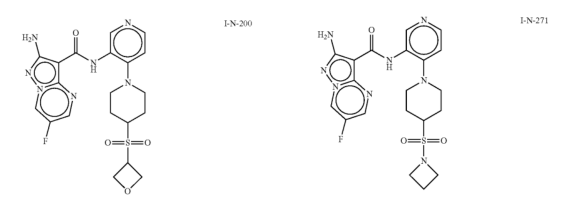

Structure in dataset:


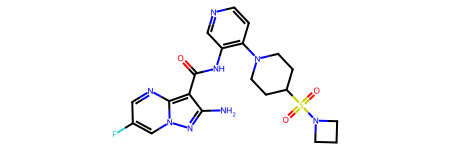

In [10]:
# Row192: Compound_I-N-200;Compound_I-N-271 have different chemical structures
from rdkit import Chem
from PIL import Image
import matplotlib.pyplot as plt

print("The actual structures of Compound_I-N-200 and Compound_I-N-271:")
img1 = Image.open('/content/drive/MyDrive/Axiom/figures/Compound_I-N-200.png')
img2 = Image.open('/content/drive/MyDrive/Axiom/figures/Compound_I-N-271.png')

plt.figure(figsize=(7, 5))
plt.subplot(1,2,1); plt.imshow(img1); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img2); plt.axis('off')
plt.show()

print("Structure in dataset:")
smiles_str = multi_compounds["smiles"].iloc[3]
mol = Chem.MolFromSmiles(smiles_str)
display(mol)

Similarly, [Row357: Compound_I-O-80;Compound_I-O-81] [Row456:	Compound_I-G-4;Compound_I-G-55]; [Row464: Compound_I-G-12;Compound_I-G-56]
have different chemical structures, and the structure in dataset need to be double-checked.

## 2. Data Distrubution

In [11]:
descriptor_columns = ["name", "smiles"]
potency_column = ["atr_binding_potency"]
toxicity_columns = [c for c in df.columns if c.endswith("_ld20") or c.endswith("_ld50")]

print("Descriptor:", descriptor_columns)
print("Potency:", potency_column)
print("Toxicity:", len(toxicity_columns), toxicity_columns)

Descriptor: ['name', 'smiles']
Potency: ['atr_binding_potency']
Toxicity: 22 ['cell_viability_ld20', 'cell_viability_ld50', 'bioactivity2_ld20', 'bioactivity2_ld50', 'ldh_ld20', 'ldh_ld50', 'cell_death_ld20', 'cell_death_ld50', 'nuclei_size_ld20', 'nuclei_size_ld50', 'mitochondria_ld20', 'mitochondria_ld50', 'er_stress_ld20', 'er_stress_ld50', 'cytoplasm_area_ld20', 'cytoplasm_area_ld50', 'bioactivity1_ld20', 'bioactivity1_ld50', 'ros_ld20', 'ros_ld50', 'halos_ld20', 'halos_ld50']


In [12]:
# Potency distribution
df[potency_column].value_counts()

,count
atr_binding_potency,
Inactive,537
< 20 nM,16


In [13]:
# Toxicity distribution
df[toxicity_columns].describe()

,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,cell_death_ld50,nuclei_size_ld20,nuclei_size_ld50,...,er_stress_ld20,er_stress_ld50,cytoplasm_area_ld20,cytoplasm_area_ld50,bioactivity1_ld20,bioactivity1_ld50,ros_ld20,ros_ld50,halos_ld20,halos_ld50
count,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,...,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000
mean,23.492081,216.525658,3.012499,290.221940,2175.647180,5882.717132,117.663627,1672.103936,101.556720,1908.459723,...,5.827142,50.453555,59.417781,1017.644292,2.894601,140.542556,62.792885,1470.628555,32.935772,257.628124
std,16.232288,466.906871,2.855050,1464.654993,3461.853413,4341.724316,605.592995,2547.526591,455.600013,2756.294660,...,5.559683,56.101516,425.719089,2288.146140,2.991922,947.012577,483.846387,2372.078240,424.985710,1092.802959
min,4.643262,27.132564,0.672593,3.408005,12.946300,109.987564,5.127331,33.584058,7.398408,58.474567,...,1.016840,4.191328,4.400932,26.537775,0.193626,2.323446,2.547933,17.581902,0.849593,4.597721
25%,11.671355,87.381689,1.265089,12.658842,57.118231,916.610170,18.210605,206.537684,26.688966,391.592119,...,2.254368,15.818007,13.310692,121.950030,0.933047,12.387573,6.416086,89.578299,4.752010,23.623700
50%,19.117532,153.979574,2.090933,28.584744,245.764314,8779.213994,36.120750,523.446917,49.114171,839.504746,...,3.825061,34.789569,24.523541,303.016587,1.870591,28.274488,11.867974,235.308557,9.336795,46.874264
75%,30.497413,241.888805,3.583990,65.409810,2451.253024,10000.000000,109.357562,1802.977651,104.532382,1730.359552,...,7.775476,64.811993,55.635441,607.985185,3.534620,54.368585,55.457494,1928.041286,20.602815,123.968088
max,108.409322,10000.000000,22.570208,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,43.912375,657.159942,10000.000000,10000.000000,19.433646,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000


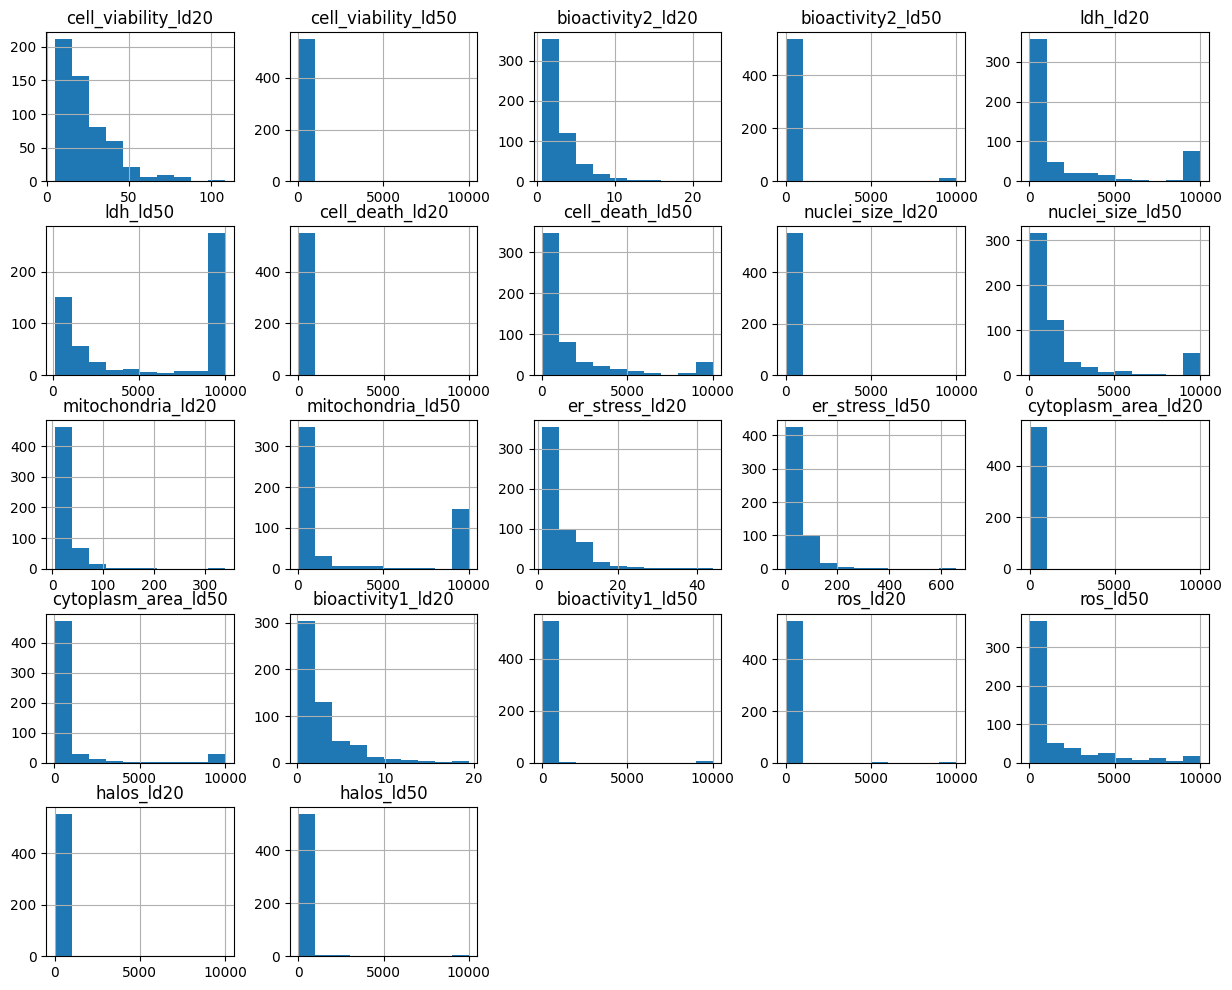

In [14]:
# Visualize toxicity values
import matplotlib.pyplot as plt

df[toxicity_columns].hist(figsize=(15, 12))
plt.savefig("/content/drive/MyDrive/Axiom/figures/01.toxicity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusions:**
1. Most toxicity values are strongly right-skewed, so log transformation is useful for data visualization and rank-based analysis.
2. Several endpoints are capped at 10,000, which should be treated as assay-range censoring rather than an exact concentration.
3. LD20 and LD50 represent different response levels and are not interchangeable across endpoints. For this analysis, LD20 is retained as the primary early-toxicity indicator, while LD50 is retained as a secondary overt-toxicity indicator.


In [15]:
# log10 transform toxicity values
import numpy as np

df_log = df.copy()

for col in toxicity_columns:
  df_log[col] = np.log10(df[col])

df_log.head()

,name,smiles,atr_binding_potency,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,...,er_stress_ld20,er_stress_ld50,cytoplasm_area_ld20,cytoplasm_area_ld50,bioactivity1_ld20,bioactivity1_ld50,ros_ld20,ros_ld50,halos_ld20,halos_ld50
0,Compound_I-N-1,NC1=NN2C=C(F)C=NC2=C1C(=O)NC1=C(C=CN=C1)N1CCN(...,< 20 nM,1.245895,2.259642,0.103791,1.308782,2.671361,4.000000,1.511023,...,0.416775,1.413846,1.258954,2.501535,-0.110807,1.244886,1.028176,2.607447,0.929221,1.658536
1,Compound_I-N-2,NC1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(CC#N)=CN3N=C2N...,Inactive,1.064879,2.005152,0.181826,1.321336,1.688205,2.985072,1.212844,...,0.326653,1.156128,1.104139,2.252316,0.136998,1.295581,0.777699,1.940713,0.555982,1.303983
2,Compound_I-N-3,CN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=...,Inactive,1.324332,2.391607,0.275077,1.598693,2.597246,4.000000,1.550583,...,0.583034,1.553937,1.392599,3.436648,0.257132,1.670836,1.023727,2.241115,0.842765,1.660068
3,Compound_I-N-4,CC(C)N1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2...,Inactive,1.187237,2.131031,0.216526,1.340297,2.647051,4.000000,1.606578,...,0.545290,1.516671,1.418296,2.691904,0.152812,1.386860,1.116153,2.378322,0.799496,1.651986
4,Compound_I-N-5,CN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=...,Inactive,1.108970,2.120066,0.139152,1.131285,2.150483,3.779478,1.387182,...,0.448658,1.337113,1.181513,2.609421,0.079173,1.235902,0.776305,2.052820,0.572588,1.499047


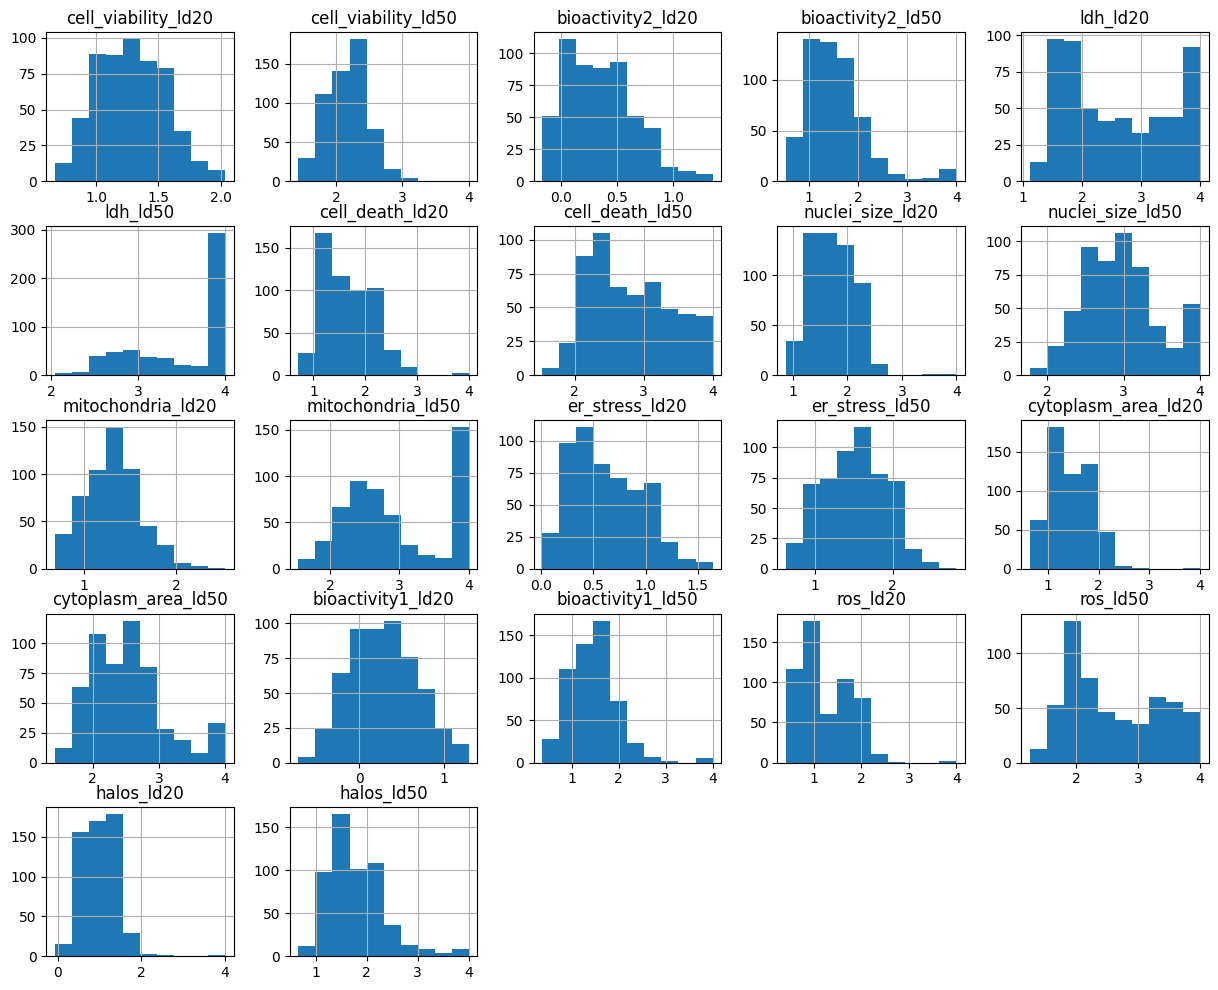

In [16]:
df_log[toxicity_columns].hist(figsize=(15, 12))
plt.savefig("/content/drive/MyDrive/Axiom/figures/02.log_toxicity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

1. Log10 transformation reduced the strong right skewness observed in toxicity endpoints.
2. Ceiling effects remained for toxicity values capped at 10,000 (log10 values are capped at 4).

## 3. Data Correlation and Relationships

### 3.1 Toxicity endpoint correlation

In [17]:
# Analyze correlation between toxicity endpoints
toxicity_columns = [c for c in df_log.columns if c.endswith("_ld20") or c.endswith("_ld50")]
ld20_columns = [c for c in toxicity_columns if "ld20" in c]
ld50_columns = [c for c in toxicity_columns if "ld50" in c]

print(len(toxicity_columns), len(ld20_columns), len(ld50_columns))

22 11 11


In [18]:
# Calculate Pearson correlation
tox_corr = df_log[toxicity_columns].corr()
tox_corr

,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,cell_death_ld50,nuclei_size_ld20,nuclei_size_ld50,...,er_stress_ld20,er_stress_ld50,cytoplasm_area_ld20,cytoplasm_area_ld50,bioactivity1_ld20,bioactivity1_ld50,ros_ld20,ros_ld50,halos_ld20,halos_ld50
cell_viability_ld20,1.000000,0.918382,0.858318,0.846647,0.904294,0.820331,0.912019,0.880917,0.930698,0.682085,...,0.843251,0.895602,0.925690,0.803814,0.835294,0.828251,0.889322,0.888087,0.781747,0.844784
cell_viability_ld50,0.918382,1.000000,0.684373,0.828596,0.787544,0.763383,0.810620,0.827776,0.865258,0.798910,...,0.684042,0.783345,0.825725,0.860879,0.701607,0.851994,0.755136,0.758266,0.629815,0.741563
bioactivity2_ld20,0.858318,0.684373,1.000000,0.790748,0.842255,0.710255,0.846896,0.735451,0.859811,0.471778,...,0.932786,0.917219,0.873730,0.638844,0.944708,0.745198,0.869384,0.809705,0.747767,0.797830
bioactivity2_ld50,0.846647,0.828596,0.790748,1.000000,0.799863,0.665760,0.838908,0.770444,0.880263,0.622096,...,0.769270,0.833864,0.858888,0.743636,0.820338,0.906942,0.798245,0.763838,0.652084,0.785143
ldh_ld20,0.904294,0.787544,0.842255,0.799863,1.000000,0.858809,0.934580,0.911810,0.914189,0.579547,...,0.836278,0.888152,0.920162,0.757734,0.813501,0.757546,0.922806,0.942948,0.825088,0.881983
ldh_ld50,0.820331,0.763383,0.710255,0.665760,0.858809,1.000000,0.809419,0.837729,0.818232,0.628354,...,0.754823,0.827694,0.808164,0.761221,0.706586,0.700672,0.784574,0.820757,0.733548,0.729817
cell_death_ld20,0.912019,0.810620,0.846896,0.838908,0.934580,0.809419,1.000000,0.898976,0.963305,0.558729,...,0.854305,0.903593,0.977021,0.747809,0.828682,0.785799,0.956897,0.914732,0.848041,0.911045
cell_death_ld50,0.880917,0.827776,0.735451,0.770444,0.911810,0.837729,0.898976,1.000000,0.873843,0.669643,...,0.743847,0.822300,0.864459,0.794382,0.707888,0.723962,0.841062,0.895538,0.744593,0.841998
nuclei_size_ld20,0.930698,0.865258,0.859811,0.880263,0.914189,0.818232,0.963305,0.873843,1.000000,0.642179,...,0.860011,0.933111,0.977716,0.801463,0.868429,0.862893,0.931839,0.884210,0.807183,0.899560
nuclei_size_ld50,0.682085,0.798910,0.471778,0.622096,0.579547,0.628354,0.558729,0.669643,0.642179,1.000000,...,0.491922,0.575970,0.576269,0.807964,0.504825,0.671789,0.479694,0.521182,0.444039,0.549992


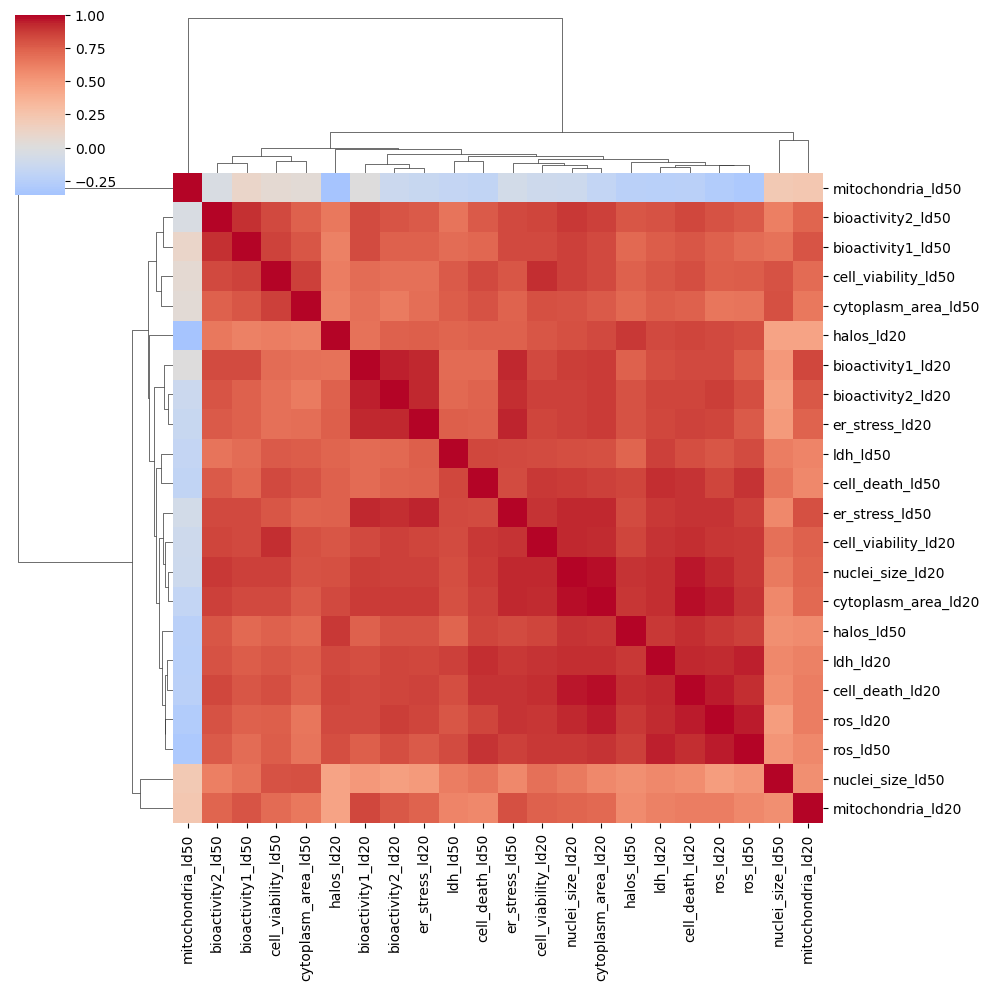

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize toxicity correlation
tox_G = sns.clustermap(tox_corr, cmap="coolwarm", center=0)
plt.show()

In [20]:
corr_pairs = tox_corr.round(3).unstack().reset_index()
corr_pairs.columns = ["endpoint1", "endpoint2", "correlation"]
corr_pairs = corr_pairs[corr_pairs["endpoint1"] < corr_pairs["endpoint2"]]
corr_pairs.sort_values(ascending=False, by="correlation")

,endpoint1,endpoint2,correlation
316,cytoplasm_area_ld20,nuclei_size_ld20,0.978
146,cell_death_ld20,cytoplasm_area_ld20,0.977
140,cell_death_ld20,nuclei_size_ld20,0.963
150,cell_death_ld20,ros_ld20,0.957
415,ros_ld20,ros_ld50,0.953
...,...,...,...
473,halos_ld50,mitochondria_ld50,-0.237
99,ldh_ld20,mitochondria_ld50,-0.244
260,mitochondria_ld50,ros_ld20,-0.285
261,mitochondria_ld50,ros_ld50,-0.315


In [21]:
# bioactivity1 and bioactivity2 correlation
corr_pairs[corr_pairs["endpoint1"].str.contains("bioactivity1") &
           corr_pairs["endpoint2"].str.contains("bioactivity2")]

,endpoint1,endpoint2,correlation
354,bioactivity1_ld20,bioactivity2_ld20,0.945
355,bioactivity1_ld20,bioactivity2_ld50,0.820
376,bioactivity1_ld50,bioactivity2_ld20,0.745
377,bioactivity1_ld50,bioactivity2_ld50,0.907


**Conclusion:**
Bioactivity1 and bioactivity2 are highly correlated, indicating substantial redundancy between these two endpoints.

In [22]:
# ld20 and ld50 correlation
ld20_ld50_corr = []

for ld20_col in toxicity_columns:
  if ld20_col.endswith("ld20"):
     ld50_col = ld20_col.replace("ld20", "ld50")
     ld20_ld50_corr.append(
         {"ld20": ld20_col,"ld50": ld50_col, "correlation": tox_corr.loc[ld20_col, ld50_col]}
     )

ld20_ld50_corr = pd.DataFrame(ld20_ld50_corr).sort_values(ascending=False, by="correlation").round(3)
ld20_ld50_corr

,ld20,ld50,correlation
9,ros_ld20,ros_ld50,0.953
6,er_stress_ld20,er_stress_ld50,0.938
0,cell_viability_ld20,cell_viability_ld50,0.918
3,cell_death_ld20,cell_death_ld50,0.899
10,halos_ld20,halos_ld50,0.888
2,ldh_ld20,ldh_ld50,0.859
8,bioactivity1_ld20,bioactivity1_ld50,0.821
1,bioactivity2_ld20,bioactivity2_ld50,0.791
7,cytoplasm_area_ld20,cytoplasm_area_ld50,0.767
4,nuclei_size_ld20,nuclei_size_ld50,0.642


**Conclusion:**
1. Most toxicity endpoints showed strong LD20-LD50 correlations, with mitochondria as a noteble exception.
2. LD20 and LD50 are complementary rather than interchangeable. I use LD20 as the primary exposure-sensitivity indicator and LD50 as a secondary severity indicator. This separation allows the analysis to distinguish an early cellular perturbation from more overt injury.


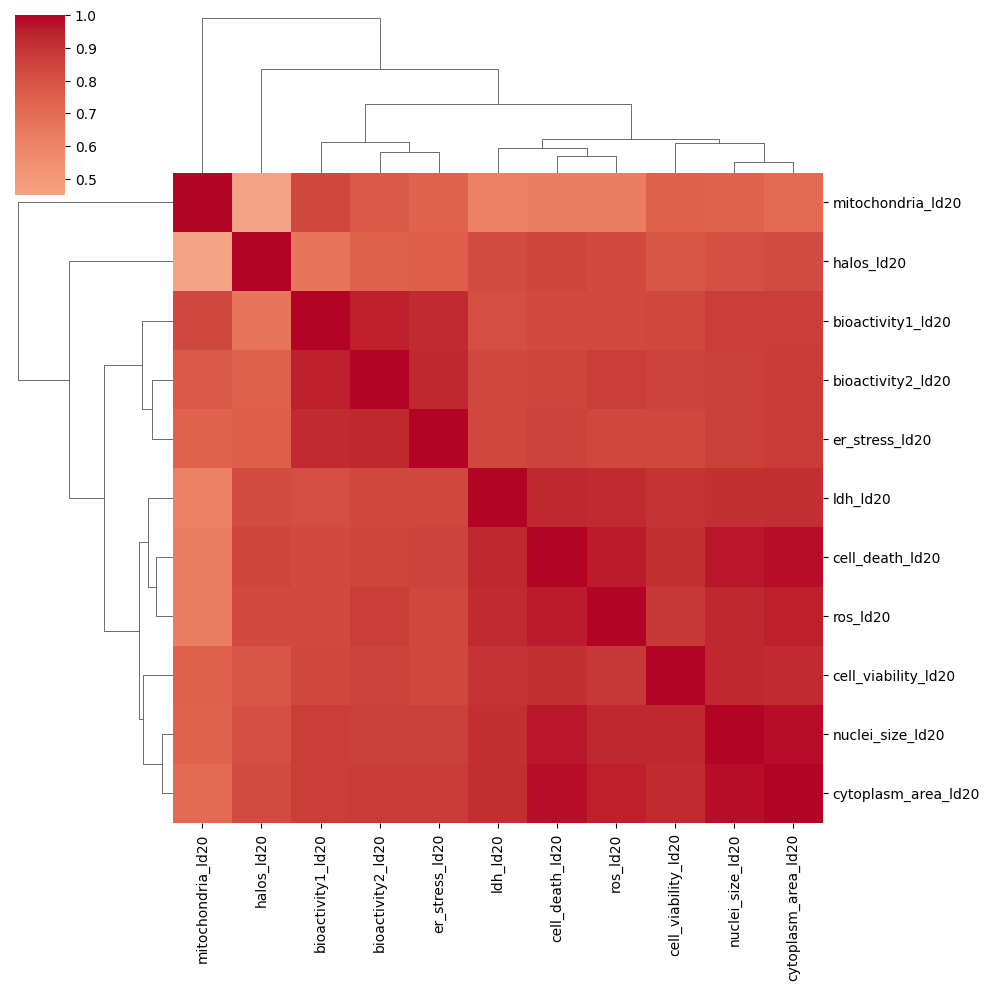

In [23]:
# Calculate Pearson correlation for LD20
ld20_tox_corr = df_log[ld20_columns].corr()

# Visualize toxicity LD20 correlation
ld20_G = sns.clustermap(ld20_tox_corr, cmap="coolwarm", center=0)
plt.show()

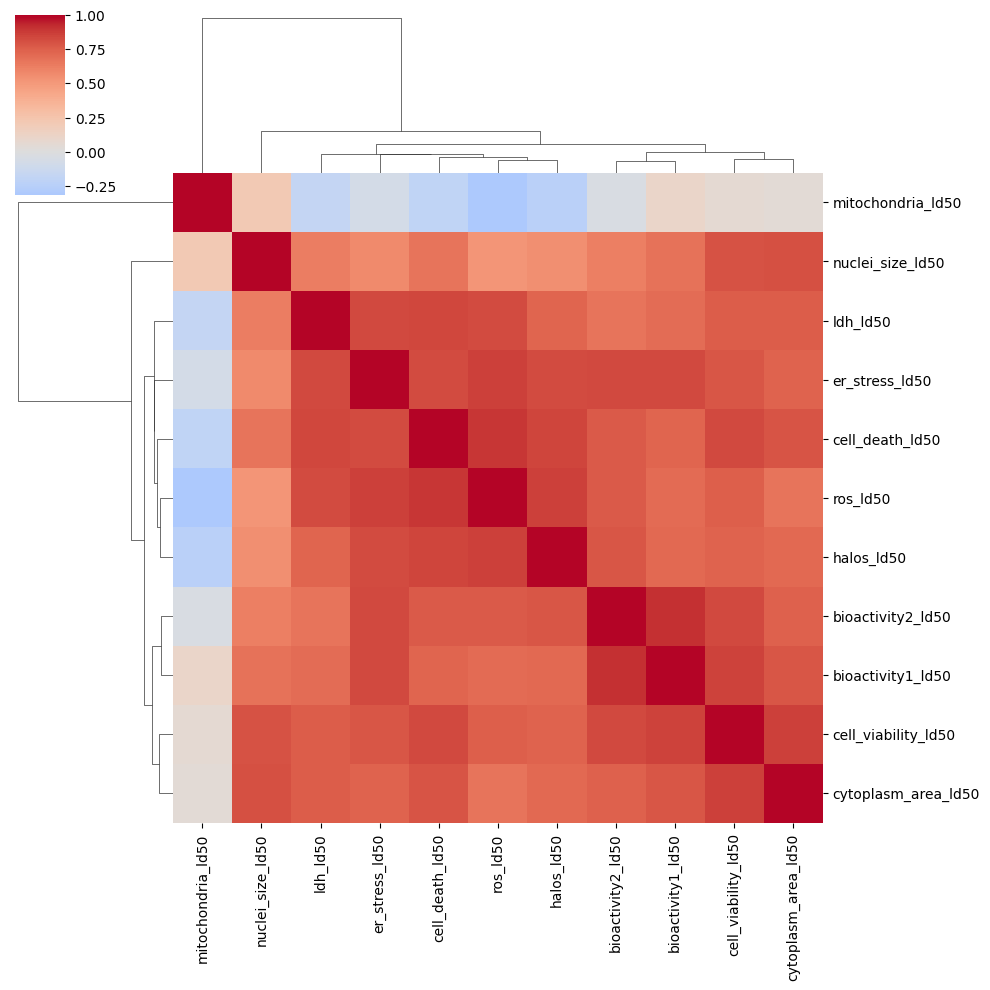

In [24]:
# Calculate Pearson correlation for LD20
ld50_tox_corr = df_log[ld50_columns].corr()

# Visualize toxicity LD20 correlation
ld50_G = sns.clustermap(ld50_tox_corr, cmap="coolwarm", center=0)
plt.show()

Conclusions:
1. Strong correlations were observed among cell_death, nuclei_size, er_stress, cytoplasm_area, ROS, etc., suggesting substantial overlap in the information provided by these toxicity endpoints.
2. Mitochondria_ld50 showed relatively weak correlations with other toxicity endpoints.

In [25]:
corr_pairs = tox_corr.round(3).unstack().reset_index()
corr_pairs.columns = ["endpoint1", "endpoint2", "correlation"]
corr_pairs = corr_pairs[corr_pairs["endpoint1"] < corr_pairs["endpoint2"]]
corr_pairs.sort_values(ascending=False, by="correlation")

,endpoint1,endpoint2,correlation
316,cytoplasm_area_ld20,nuclei_size_ld20,0.978
146,cell_death_ld20,cytoplasm_area_ld20,0.977
140,cell_death_ld20,nuclei_size_ld20,0.963
150,cell_death_ld20,ros_ld20,0.957
415,ros_ld20,ros_ld50,0.953
...,...,...,...
473,halos_ld50,mitochondria_ld50,-0.237
99,ldh_ld20,mitochondria_ld50,-0.244
260,mitochondria_ld50,ros_ld20,-0.285
261,mitochondria_ld50,ros_ld50,-0.315


In [26]:
corr_pairs.sort_values(ascending=False, by="correlation", key=lambda x: x.abs())

,endpoint1,endpoint2,correlation
316,cytoplasm_area_ld20,nuclei_size_ld20,0.978
146,cell_death_ld20,cytoplasm_area_ld20,0.977
140,cell_death_ld20,nuclei_size_ld20,0.963
150,cell_death_ld20,ros_ld20,0.957
415,ros_ld20,ros_ld50,0.953
...,...,...,...
297,er_stress_ld50,mitochondria_ld50,-0.078
33,cell_viability_ld50,mitochondria_ld50,0.057
341,cytoplasm_area_ld50,mitochondria_ld50,0.048
77,bioactivity2_ld50,mitochondria_ld50,-0.032


In [27]:
# Identify strongly correlated pairs with a threshold
threshold = 0.90

strong_corr = corr_pairs[corr_pairs["correlation"].abs() >= threshold]
print("Strongly correlated pairs:\n", strong_corr.sort_values(ascending=False, by=["correlation"]))
print("Number of strongly correlated pairs:", len(strong_corr))

Strongly correlated pairs:
                endpoint1            endpoint2  correlation
316  cytoplasm_area_ld20     nuclei_size_ld20        0.978
146      cell_death_ld20  cytoplasm_area_ld20        0.977
140      cell_death_ld20     nuclei_size_ld20        0.963
150      cell_death_ld20             ros_ld20        0.957
415             ros_ld20             ros_ld50        0.953
326  cytoplasm_area_ld20             ros_ld20        0.952
354    bioactivity1_ld20    bioactivity2_ld20        0.945
107             ldh_ld20             ros_ld50        0.943
277       er_stress_ld20       er_stress_ld50        0.938
136      cell_death_ld20             ldh_ld20        0.935
321  cytoplasm_area_ld20       er_stress_ld50        0.933
294       er_stress_ld50     nuclei_size_ld20        0.933
56     bioactivity2_ld20       er_stress_ld20        0.933
194     nuclei_size_ld20             ros_ld20        0.932
8    cell_viability_ld20     nuclei_size_ld20        0.931
365    bioactivity1_ld20    

In [28]:
# Identify correlation hubs
hubs = pd.concat([strong_corr["endpoint1"], strong_corr["endpoint2"]]).value_counts()
print(hubs)

cell_death_ld20        8
ldh_ld20               7
er_stress_ld50         7
nuclei_size_ld20       7
ros_ld20               6
cytoplasm_area_ld20    6
cell_viability_ld20    5
bioactivity2_ld20      3
bioactivity1_ld20      3
er_stress_ld20         3
ros_ld50               3
halos_ld50             2
cell_death_ld50        1
bioactivity1_ld50      1
cell_viability_ld50    1
bioactivity2_ld50      1
Name: count, dtype: int64


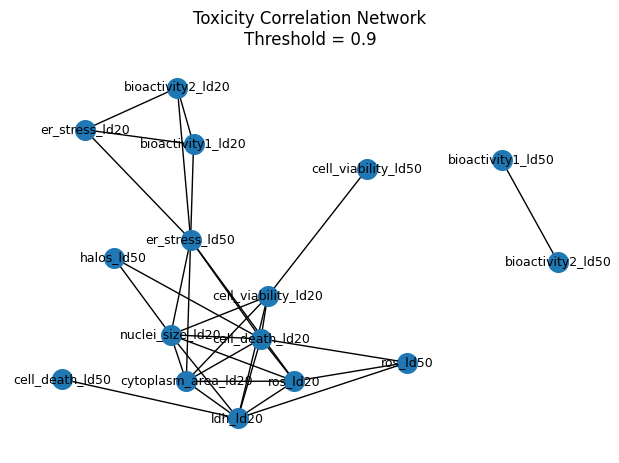

In [29]:
# Toxicity Correlation Network
import networkx as nx
import matplotlib.pyplot as plt

total_G = nx.Graph()

for _, row in strong_corr.iterrows():
    total_G.add_edge(row["endpoint1"], row["endpoint2"])

plt.figure(figsize=(6, 4))
pos = nx.spring_layout(total_G, seed=10, k=1)
nx.draw(total_G, pos, with_labels=True, node_size=200, font_size=9)
plt.title(f"Toxicity Correlation Network\nThreshold = {threshold}")
plt.show()

In [30]:
# Find strongly correlated ld20 pairs with |r| >= threshold
ld20_strong_corr = corr_pairs[
    corr_pairs["endpoint1"].isin(ld20_columns)
    & corr_pairs["endpoint2"].isin(ld20_columns)
    & (corr_pairs["correlation"].abs() >= threshold)
]
print("Strongly correlated ld20 pairs:\n", ld20_strong_corr.sort_values(ascending=False, by=["correlation"]))
print("Number of strongly correlated ld20 pairs:", len(ld20_strong_corr))
print("\n")

# Find strongly correlated ld50 pairs with |r| >= threshold
ld50_strong_corr = corr_pairs[
    corr_pairs["endpoint1"].isin(ld50_columns)
    & corr_pairs["endpoint2"].isin(ld50_columns)
    & (corr_pairs["correlation"].abs() >= threshold)
]
print("Strongly correlated ld50 pairs:\n", ld50_strong_corr.sort_values(ascending=False, by=["correlation"]))
print("Number of strongly correlated ld50 pairs:", len(ld50_strong_corr))

Strongly correlated ld20 pairs:
                endpoint1            endpoint2  correlation
316  cytoplasm_area_ld20     nuclei_size_ld20        0.978
146      cell_death_ld20  cytoplasm_area_ld20        0.977
140      cell_death_ld20     nuclei_size_ld20        0.963
150      cell_death_ld20             ros_ld20        0.957
326  cytoplasm_area_ld20             ros_ld20        0.952
354    bioactivity1_ld20    bioactivity2_ld20        0.945
136      cell_death_ld20             ldh_ld20        0.935
56     bioactivity2_ld20       er_stress_ld20        0.933
194     nuclei_size_ld20             ros_ld20        0.932
8    cell_viability_ld20     nuclei_size_ld20        0.931
364    bioactivity1_ld20       er_stress_ld20        0.927
14   cell_viability_ld20  cytoplasm_area_ld20        0.926
106             ldh_ld20             ros_ld20        0.923
312  cytoplasm_area_ld20             ldh_ld20        0.920
96              ldh_ld20     nuclei_size_ld20        0.914
132      cell_death_ld2

**Conclusions:**
1. Several LD20 endpoints are strongly correlated, indicating that some endpoints capture overlapping early toxicity response.
2. Correlated endpoints should be grouped by phenotype so that the same biological process is not counted multiple times.

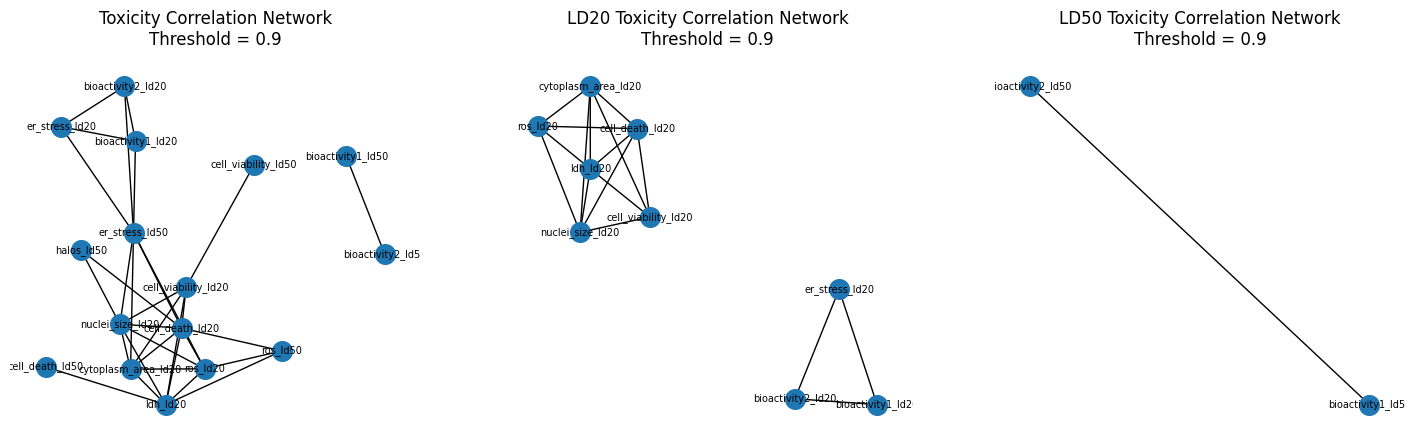

In [31]:
# Draw Toxicity Correlation Networks
import networkx as nx
import matplotlib.pyplot as plt

total_G = nx.Graph()
for _, row in strong_corr.iterrows():
    total_G.add_edge(row["endpoint1"], row["endpoint2"])

ld20_G = nx.Graph()
for _, row in ld20_strong_corr.iterrows():
    ld20_G.add_edge(row["endpoint1"], row["endpoint2"])

ld50_G = nx.Graph()
for _, row in ld50_strong_corr.iterrows():
    ld50_G.add_edge(row["endpoint1"], row["endpoint2"])

pos_total = nx.spring_layout(total_G, seed=10, k=1)
pos_ld20 = nx.spring_layout(ld20_G, seed=10, k=1)
pos_ld50 = nx.spring_layout(ld50_G, seed=10, k=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nx.draw(total_G, pos_total, ax=axes[0], with_labels=True, node_size=200, font_size=7)
axes[0].set_title(f"Toxicity Correlation Network\nThreshold = {threshold}")

nx.draw(ld20_G, pos_ld20, ax=axes[1], with_labels=True, node_size=200, font_size=7)
axes[1].set_title(f"LD20 Toxicity Correlation Network\nThreshold = {threshold}")

nx.draw(ld50_G, pos_ld50, ax=axes[2], with_labels=True, node_size=200, font_size=7)
axes[2].set_title(f"LD50 Toxicity Correlation Network\nThreshold = {threshold}")

plt.savefig("/content/drive/MyDrive/Axiom/figures/04.log_toxicity correlation network (threshold=0.95).png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**
Cytoplasma_area, cell_death, ros, and nuclei_size are highly correlated, suggesting that these endpoints may capture overlapping cellular responses.

**Limitation:**
Current exposure-response data identify phenotypes that are strongly correlated and differ in exposure sensitivity, but they do not establish temporal ordering or causal direction. Time-course experiments are still needed to establish temporal ordering and causality.

### 3.2 Define a composite toxicity score (CTS)

The analysis separates two concepts:

- **Early exposure sensitivity:** LD20 endpoints are the primary layer because the Axiom MOS framework is anchored to an early exposure response.
- **Overt cellular injury:** LD50 endpoints are retained as a complementary layer describing stronger injury.

Because several endpoints are highly correlated, I first aggregate them into phenotype domains rather than giving every endpoint equal weight. Higher scores indicate a larger concentration margin to the measured toxicity phenotype (i.e., a more favorable profile).


In [32]:
# Define phenotype groups for the primary LD20 analysis
# Grouping prevents highly correlated readouts from being counted multiple times
ld20_groups = {
    "general_injury": ["cell_viability_ld20", "ldh_ld20", "cell_death_ld20"],
    "morphology": ["nuclei_size_ld20", "cytoplasm_area_ld20", "halos_ld20"],
    "mitochondrial": ["mitochondria_ld20"],
    "er_stress": ["er_stress_ld20"],
    "oxidative_stress": ["ros_ld20"],
    "bioactivity": ["bioactivity1_ld20", "bioactivity2_ld20"],
}

# Define phenotype groups for the secondary LD50 analysis
ld50_groups = {
    "general_injury": ["cell_viability_ld50", "ldh_ld50", "cell_death_ld50"],
    "morphology": ["nuclei_size_ld50", "cytoplasm_area_ld50", "halos_ld50"],
    "mitochondrial": ["mitochondria_ld50"],
    "er_stress": ["er_stress_ld50"],
    "oxidative_stress": ["ros_ld50"],
    "bioactivity": ["bioactivity1_ld50", "bioactivity2_ld50"],
}

In [33]:
censor_limit = 4

# Identify censored measurements
df_log["n_censored"] = (df_log[toxicity_columns] >= censor_limit).sum(axis=1)

print(df_log["n_censored"].value_counts())

n_censored
1     266
0     159
2      64
3      41
4      12
6       6
5       3
13      1
10      1
Name: count, dtype: int64


In [34]:
# Define a function to calculate censor_aware_percentile rank
def censor_aware_percentile(series, censor_limit=censor_limit):
    s = series.copy()
    censored = s >= censor_limit
    observed = s[~censored & s.notna()]

    ranks = pd.Series(np.nan, index=s.index)

    # Rank observed values only
    ranks.loc[observed.index] = (
        observed.rank(pct=True, method="average")
    )

    # Right-censored values are assigned the maximum percentile.
    if len(observed) > 0:
        ranks.loc[censored] = 1.0

    return ranks

In [35]:
# Primary score: phenotype-level percentile ranks of LD20 values.

ld20_group_scores = pd.DataFrame(index=df_log.index)

for group, cols in ld20_groups.items():
    # Calculate censor_aware_percentile rank for each phenotype within each group
    ranks = df_log[cols].apply(censor_aware_percentile, censor_limit=4)
    # Calculate censor_aware_percentile rank average within each group
    ld20_group_scores[group] = ranks.mean(axis=1)

# Assign equal weight across phenotype groups, not across individual endpoints
df_log["ld20_cts"] = ld20_group_scores.mean(axis=1)

print(ld20_group_scores.describe().round(3))
print("Primary score:\n", df_log["ld20_cts"].describe().round(3))

       general_injury  morphology  mitochondrial  er_stress  oxidative_stress  \
count         553.000     553.000        553.000    553.000           553.000   
mean            0.523       0.502          0.501      0.501             0.502   
std             0.293       0.280          0.289      0.289             0.289   
min             0.003       0.002          0.002      0.002             0.002   
25%             0.275       0.240          0.251      0.251             0.252   
50%             0.518       0.481          0.501      0.501             0.502   
75%             0.795       0.755          0.750      0.750             0.752   
max             0.999       0.998          1.000      1.000             1.000   

       bioactivity  
count      553.000  
mean         0.501  
std          0.286  
min          0.005  
25%          0.245  
50%          0.507  
75%          0.744  
max          1.000  
Primary score:
 count    553.000
mean       0.505
std        0.271
min        0.0

In [36]:
# Secondary score: phenotype-level percentile ranks of LD50 values.
ld50_group_scores = pd.DataFrame(index=df_log.index)

for group, cols in ld50_groups.items():
    # Calculate censor_aware_percentile rank for each phenotype within each group
    ranks = df_log[cols].apply(censor_aware_percentile, censor_limit=4)
    # Calculate censor_aware_percentile rank average within each group
    ld50_group_scores[group] = ranks.mean(axis=1)

# Assign equal weight across phenotype groups, not across individual endpoints
df_log["ld50_cts"] = ld50_group_scores.mean(axis=1)

print(ld50_group_scores.describe().round(3))
print("Secondary score:\n", df_log["ld50_cts"].describe().round(3))

       general_injury  morphology  mitochondrial  er_stress  oxidative_stress  \
count         553.000     553.000        553.000    553.000           553.000   
mean            0.592       0.526          0.634      0.501             0.513   
std             0.289       0.279          0.332      0.289             0.295   
min             0.002       0.002          0.002      0.002             0.002   
25%             0.340       0.275          0.342      0.251             0.257   
50%             0.664       0.547          0.682      0.501             0.513   
75%             0.839       0.769          1.000      0.750             0.769   
max             1.000       1.000          1.000      1.000             1.000   

       bioactivity  
count      553.000  
mean         0.509  
std          0.291  
min          0.003  
25%          0.255  
50%          0.519  
75%          0.758  
max          1.000  
Secondary score:
 count    553.000
mean       0.546
std        0.236
min        0

### 3.3 Potency-Toxicity correlation

In [37]:
df_log["active"] = df_log["atr_binding_potency"].str.contains("<").astype(int)

# Point-biserial correlation between ATR binding potency and CTS
from scipy.stats import pointbiserialr

results = []

for col in toxicity_columns:
    r, p = pointbiserialr(df_log["active"], df_log[col])
    results.append({"endpoint": col, "r": r, "p": p})

r1, p1 = pointbiserialr(df_log["active"], df_log["ld20_cts"])
r2, p2 = pointbiserialr(df_log["active"], df_log["ld50_cts"])
results.append({"endpoint": "ld20_cts", "r": r1, "p": p1})
results.append({"endpoint": "ld50_cts", "r": r2, "p": p2})

act_tox_corr = pd.DataFrame(results)
act_tox_corr

,endpoint,r,p
0,cell_viability_ld20,-0.030933,0.467878
1,cell_viability_ld50,-0.032769,0.441853
2,bioactivity2_ld20,-0.059570,0.161839
3,bioactivity2_ld50,-0.047390,0.265916
4,ldh_ld20,-0.019234,0.651750
5,ldh_ld50,-0.042092,0.323141
6,cell_death_ld20,-0.024170,0.570590
7,cell_death_ld50,-0.018044,0.672004
8,nuclei_size_ld20,-0.042672,0.316509
9,nuclei_size_ld50,-0.016149,0.704736


**Conclusion:**
No strong correlation was observed between ATR binding activity status and the toxicity endpoints in this dataset.

**Limitations:** The potency variable is binarized and heavily imbalanced (16 active vs. 537 inactive compounds).

Because ATR potency is available only as <20 nM versus inactive in this dataset, a true quantitative potency-vs-toxicity Pareto frontier cannot be constructed from the current table. If quantitative Kd/IC50 values become available, a potency-toxicity trade-off analysis can also be performed with log10 potency vs. toxicity score.


### 3.4 Clinical and non-clinical benchmarks

In [38]:
actives = df_log[df_log["atr_binding_potency"].str.contains("< 20 nM")]
actives[["name", "ld20_cts", "ld50_cts"]].sort_values(ascending=False, by="ld20_cts")

,name,ld20_cts,ld50_cts
447,Compound_I-C-79,0.942305,0.836515
263,Compound_I-N-275,0.865254,0.916552
175,Compound_I-N-182;Compound_I-N-186,0.759816,0.820837
399,Compound_I-C-31,0.744259,0.799427
472,Compound_I-G-21,0.645341,0.645491
482,Compound_I-G-32,0.574276,0.460792
0,Compound_I-N-1,0.399573,0.609784
112,Compound_I-N-118,0.392678,0.476746
11,Compound_I-N-13,0.382963,0.530710
56,Compound_I-N-58,0.346488,0.528393


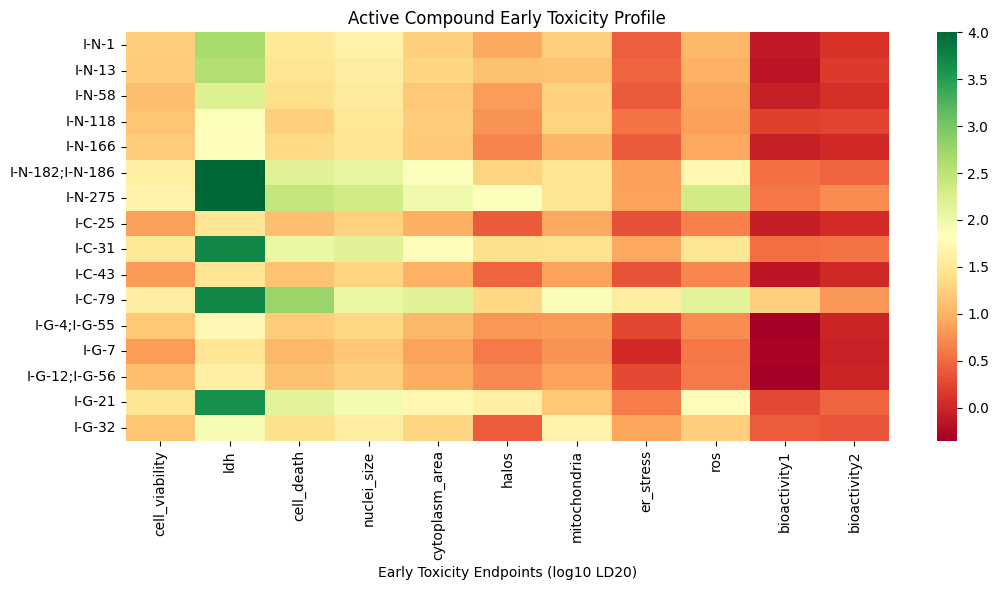

In [39]:
# Early Toxicity profile heatmap of active compounds
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

sns.heatmap(
    actives[[c for cols in ld20_groups.values() for c in cols]],
    xticklabels=[x.replace("_ld20", "") for x in [c for cols in ld20_groups.values() for c in cols]],
    yticklabels=actives["name"].str.replace("Compound_", ""),
    cmap="RdYlGn"
)

plt.xlabel("Early Toxicity Endpoints (log10 LD20)")
plt.title("Active Compound Early Toxicity Profile")
plt.savefig("/content/drive/MyDrive/Axiom/figures/05.Active Compound Early Toxicity Profile.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


- **Clinical benchmarks:** I-G-32 / Gartisertib (clinical toxicity benchmark), I-C-79 / Tuvusertib (clinically favorable benchmark).
- **Non-clinical benchmarks:** I-N-275, I-N-182/186, I-C-31, Compound_I-G-21.

In [40]:
# Benchmark table
benchmark_names = ["Compound_I-G-32", "Compound_I-C-79", "Compound_I-N-275", "Compound_I-N-182;Compound_I-N-186", "Compound_I-C-31", "Compound_I-G-21"]
benchmark_table = df_log[df_log["name"].isin(benchmark_names)][["name", "atr_binding_potency", "ld20_cts", "ld50_cts", "n_censored"]].copy()
benchmark_table.sort_values("ld20_cts", ascending=False)


,name,atr_binding_potency,ld20_cts,ld50_cts,n_censored
447,Compound_I-C-79,< 20 nM,0.942305,0.836515,2
263,Compound_I-N-275,< 20 nM,0.865254,0.916552,3
175,Compound_I-N-182;Compound_I-N-186,< 20 nM,0.759816,0.820837,3
399,Compound_I-C-31,< 20 nM,0.744259,0.799427,3
472,Compound_I-G-21,< 20 nM,0.645341,0.645491,1
482,Compound_I-G-32,< 20 nM,0.574276,0.460792,0


The trends in ld20_cts and ld50_cts are generally consistent. Therefore, I will use ld20_cts as the primary tox_score, with ld50_cts as complementary. CTS is an exploratory dataset-derived evaluation metric, not a validated clinical-risk probability.

In [41]:
# Tox_score can be adjusted to incorporate both ld20_cts and ld50_cts.
df_log["tox_score"] = df_log["ld20_cts"]

## 4. Chemical Space Exploration

### 4.1 Hierarchical clustering based on Tanimoto Similarity

In [42]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convert smiles to mol2
mols = [Chem.MolFromSmiles(s) for s in df_log["smiles"]]

# Generate Morgan Fingerprints (radius = 2, 2048 bits)
fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048) for mol in mols]


# Calculate Tanimoto distance matrix
n = len(fps)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        distance_matrix[i, j] = 1 - similarity

[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerator
[02:46:51] DEPRECATION WARNING: please use MorganGenerat

In [43]:
# Calculate the lowest similarity in the dataset
active_distance = distance_matrix[np.ix_(actives.index, actives.index)]
print(active_distance.shape)
print("min similarity in active compounds:", 1 - active_distance.max())
print("min similarity in dataset:", 1 - distance_matrix.max())

(16, 16)
min similarity in active compounds: 0.36904761904761907
min similarity in dataset: 0.1339285714285714


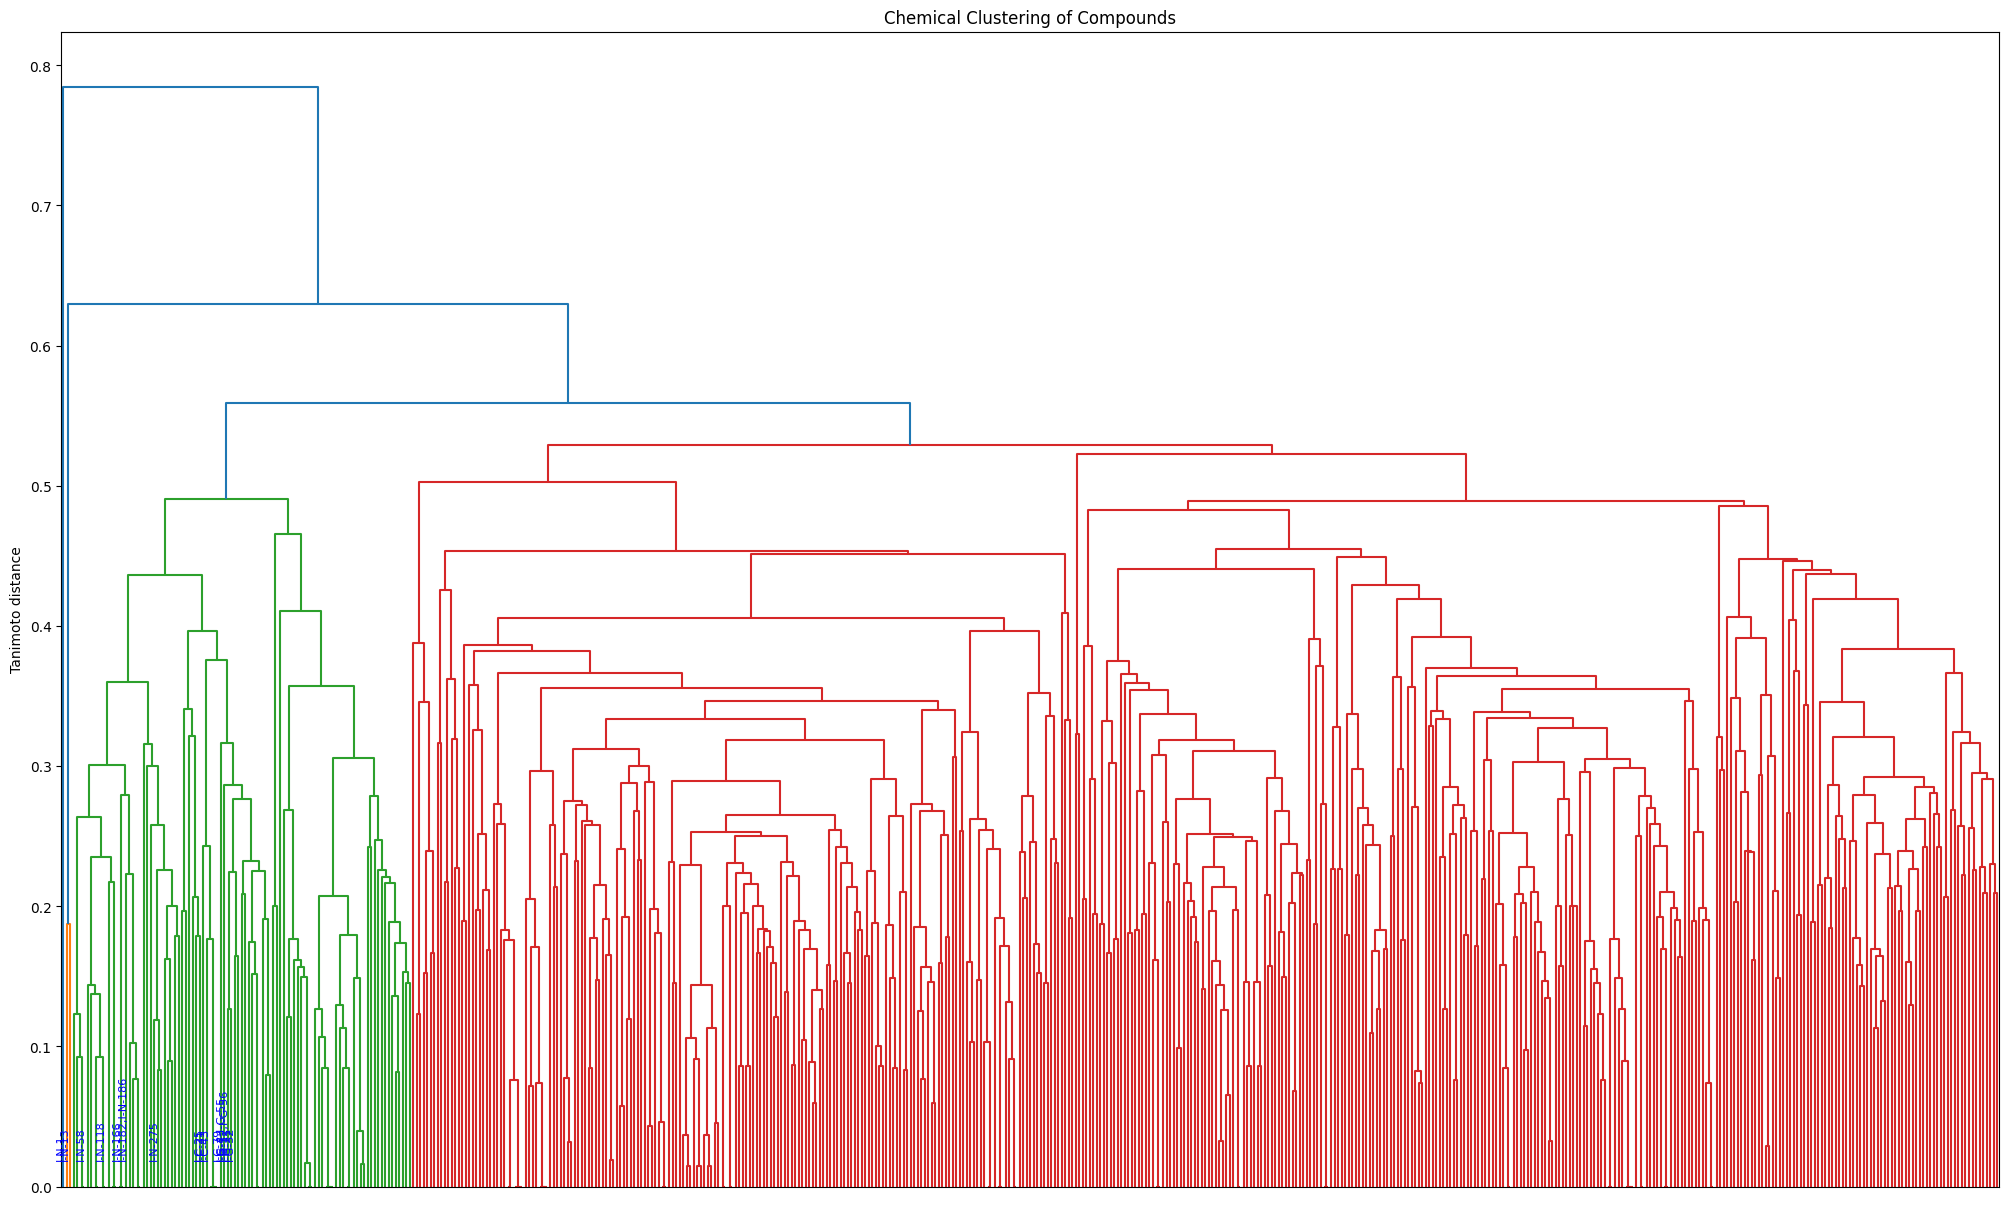

In [44]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# Convert the square matrix to a condensed 1D distance vector
condensed_matrix = squareform(distance_matrix)

# Perform Hierarchical clustering
Z = linkage(condensed_matrix, method="average")

# Plot the resulting dendrogram
plt.figure(figsize=(25, 15))
d = dendrogram(Z, labels=df["name"].tolist(), leaf_rotation=90, leaf_font_size=9, no_labels=True)

# Mark active compounds in dendrogram
active_names = set(actives["name"])

for x, name in zip(d["leaves"], [df["name"].iloc[i] for i in d["leaves"]]):
    if name in active_names:
        plt.text(x, 0.02, name.replace("Compound_", ""), rotation=90, fontsize=8, color="blue", ha="center")

plt.ylabel("Tanimoto distance")
plt.title("Chemical Clustering of Compounds")
plt.savefig("/content/drive/MyDrive/Axiom/figures/06.Chemical Clustering of All Compounds.png", dpi=300, bbox_inches="tight")
plt.show()

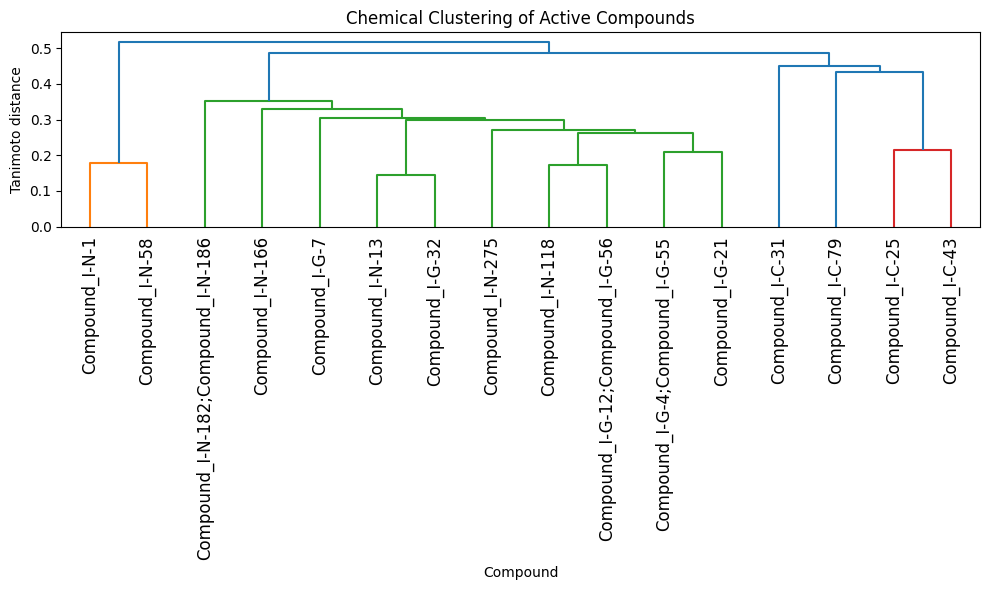

In [45]:
# Convert the square matrix to a condensed 1D distance vector
condensed_active_distance = squareform(active_distance)

# Perform Hierarchical clustering
Za = linkage(condensed_active_distance, method="average")

# Plot the resulting dendrogram for active compounds
plt.figure(figsize=(10, 6))

dendrogram(Za, labels = actives["name"].values, leaf_rotation = 90)

plt.xlabel("Compound")
plt.ylabel("Tanimoto distance")
plt.title("Chemical Clustering of Active Compounds")
plt.savefig("/content/drive/MyDrive/Axiom/figures/07.Chemical Clustering of Active Compounds.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### 4.2 MCS Analysis

MCS for All Compound: 17 common atoms
MCS for Active Compound: 19 common atoms


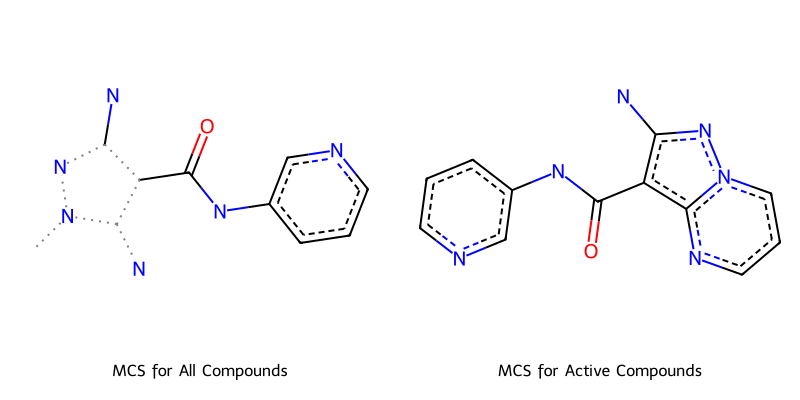

In [46]:
# Maximum Common Scaffold (MCS) Analysis
from rdkit.Chem import rdFMCS, Draw

# Find MCS among all compounds
mcs = rdFMCS.FindMCS(mols)
print(f"MCS for All Compound: {mcs.numAtoms} common atoms")

# Find MCS among active compounds
active_mols = [Chem.MolFromSmiles(s) for s in actives["smiles"]]
active_mcs = rdFMCS.FindMCS(active_mols)
print(f"MCS for Active Compound: {active_mcs.numAtoms} common atoms")

# Convert MCS smartsString to mol
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
active_mcs_mol = Chem.MolFromSmarts(active_mcs.smartsString)

# Draw MCS
img = Draw.MolsToGridImage(
    [mcs_mol, active_mcs_mol],
    legends=["MCS for All Compounds", "MCS for Active Compounds"],
    molsPerRow=2,
    subImgSize=(400, 400)
)

display(img)

553 1


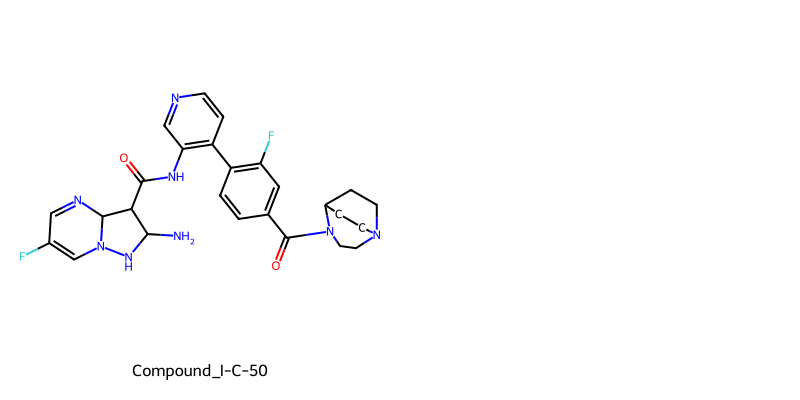

In [47]:
from rdkit import Chem
from rdkit.Chem import Draw

# Compounds That Do Not Match the Active MCS
mols = [Chem.MolFromSmiles(s) for s in df_log["smiles"]]
non_matching = []

for i, mol in enumerate(mols):
    if not mol.HasSubstructMatch(active_mcs_mol):
        non_matching.append((df_log.iloc[i]["name"], mol))

print(len(mols), len(non_matching))

non_matching_names = [x[0] for x in non_matching]
non_matching_mols = [x[1] for x in non_matching]

img = Draw.MolsToGridImage(
    non_matching_mols,
    legends=non_matching_names,
    molsPerRow=2,
    subImgSize=(400, 400)
)

display(img)

Index([418], dtype='int64')
553 552
MCS for the Rest Compounds: 19 common atoms


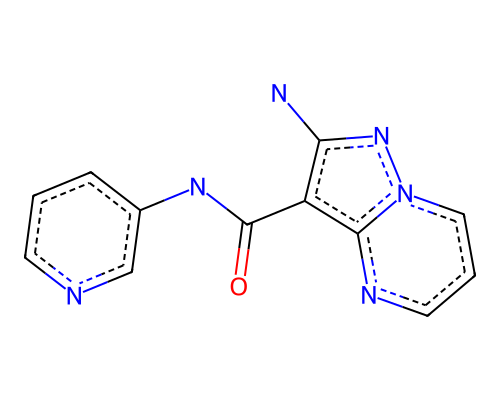

In [48]:
print(df[df["name"].str.contains("Compound_I-C-50")].index)

mols_uni = mols[:418] + mols[419:]
print(len(mols), len(mols_uni))

# Find MCS among the rest compounds after removing I-C-50
mcs_uni = rdFMCS.FindMCS(mols_uni)
print(f"MCS for the Rest Compounds: {mcs_uni.numAtoms} common atoms")

# Convert MCS smartsString to mol
mcs_uni_mol = Chem.MolFromSmarts(mcs_uni.smartsString)

# Draw MCS
display(
    Draw.MolToImage(
        mcs_uni_mol,
        size=(500, 400)
    )
)

### 4.3 Bemis–Murcko Scaffolds

In [52]:
# Generate Bemis–Murcko scaffolds
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
df_log["scaffold"] = df_log["smiles"].apply(MurckoScaffold.MurckoScaffoldSmiles)

In [53]:
df_log["scaffold"].describe()

,scaffold
count,553
unique,221
top,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
freq,45


In [54]:
scaffold_sizes = df_log["scaffold"].value_counts()
print(scaffold_sizes)

scaffold
O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12                           45
O=C(Nc1cnccc1N1CCCCC1)c1cnn2cccnc12                           39
O=C(Nc1cccnc1)c1cnn2cccnc12                                   30
O=C(Nc1cnccc1N1CCC(C(=O)N2CCC2)CC1)c1cnn2cccnc12              20
O=C(Nc1cnccc1N1CCC(C(=O)N2CCNCC2)CC1)c1cnn2cccnc12            15
                                                              ..
O=C(Nc1cnccc1N1CCC(C(=O)N2CCC3(COC3)C2)CC1)c1cnn2cccnc12       1
O=C(Nc1cnccc1N1CCC(C(=O)N2CC3(CCO3)C2)CC1)c1cnn2cccnc12        1
O=C(Nc1cnccc1N1CCC(C(=O)N2CC[NH2+]CC2)CC1)c1cnn2cccnc12        1
O=C(Nc1cnccc1N1CCC(C(=O)N2CCN(C3CNC3)CC2)CC1)c1cnn2cccnc12     1
O=C(Nc1cnccc1N1CCC(N2CC3(COC3)C2)CC1)c1cnn2cccnc12             1
Name: count, Length: 221, dtype: int64


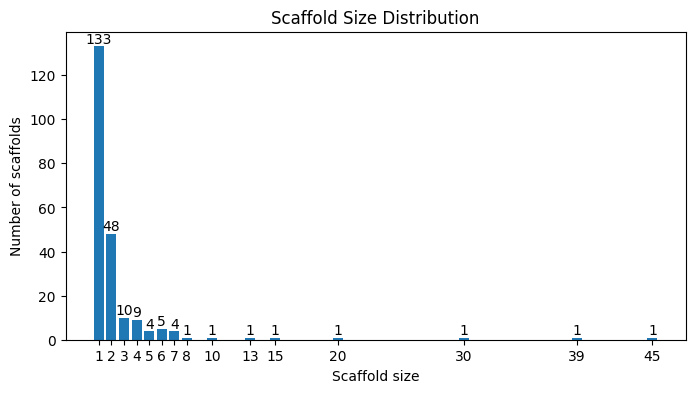

In [55]:
# Scaffold size distribution
import matplotlib.pyplot as plt

scaffold_size_dist = scaffold_sizes.value_counts().sort_index()

plt.figure(figsize=(8, 4))

bars = plt.bar(scaffold_size_dist.index, scaffold_size_dist.values)
plt.bar_label(bars)
plt.xticks(scaffold_size_dist.index)

plt.xlabel("Scaffold size")
plt.ylabel("Number of scaffolds")
plt.title("Scaffold Size Distribution")
plt.savefig("/content/drive/MyDrive/Axiom/figures/08.scaffold_size_distribution.png", dpi=300, bbox_inches="tight")

In [56]:
# Calculate n_compounds, n_active, n_inactive in each scaffold group
scaffold_groups = df_log.groupby("scaffold").agg(
    n_compounds=("name", "count"),
    n_active = ("atr_binding_potency", lambda x : x.str.contains("<").sum()),
    n_inactive =  ("atr_binding_potency", lambda x : x.str.contains("Inactive").sum())
).reset_index().sort_values("n_compounds", ascending=False)

# Assign a scaffold_id to each scaffold from the largest group to the smallest group
scaffold_groups["scaffold_id"] = range(1, len(scaffold_groups) + 1)

# Calculate the active rate for each scaffold
scaffold_groups["active_rate"] = scaffold_groups["n_active"] / scaffold_groups["n_compounds"]
scaffold_groups.head()

,scaffold,n_compounds,n_active,n_inactive,scaffold_id,active_rate
183,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12,45,2,43,1,0.044444
135,O=C(Nc1cnccc1N1CCCCC1)c1cnn2cccnc12,39,0,39,2,0.000000
0,O=C(Nc1cccnc1)c1cnn2cccnc12,30,0,30,3,0.000000
72,O=C(Nc1cnccc1N1CCC(C(=O)N2CCC2)CC1)c1cnn2cccnc12,20,1,19,4,0.050000
86,O=C(Nc1cnccc1N1CCC(C(=O)N2CCNCC2)CC1)c1cnn2ccc...,15,2,13,5,0.133333


In [57]:
# Identify promising scaffolds.
# Require both activity enrichment and a minimum sample size; active_rate alone can be unstable
# for scaffolds represented by only one compound.
min_scaffold_n = 3
promising_scaffolds = scaffold_groups[
    (scaffold_groups["n_active"] >= 1) &
    (scaffold_groups["n_compounds"] >= min_scaffold_n)
].sort_values(
    ["n_active", "active_rate", "n_compounds"], ascending=[False, False, False]
)
promising_scaffolds


,scaffold,n_compounds,n_active,n_inactive,scaffold_id,active_rate
161,O=C(Nc1cnccc1N1CCN(C2COC2)CC1)c1cnn2cccnc12,13,3,10,6,0.230769
16,O=C(Nc1cnccc1-c1ccc(C(=O)N2CCNCC2)cc1)c1cnn2cc...,4,2,2,27,0.500000
86,O=C(Nc1cnccc1N1CCC(C(=O)N2CCNCC2)CC1)c1cnn2ccc...,15,2,13,5,0.133333
183,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12,45,2,43,1,0.044444
81,O=C(Nc1cnccc1N1CCC(C(=O)N2CCN3CCC2CC3)CC1)c1cn...,3,1,2,31,0.333333
171,O=C(Nc1cnccc1N1CCN2C(=O)CCC2C1)c1cnn2cccnc12,4,1,3,30,0.250000
33,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12,7,1,6,9,0.142857
72,O=C(Nc1cnccc1N1CCC(C(=O)N2CCC2)CC1)c1cnn2cccnc12,20,1,19,4,0.050000


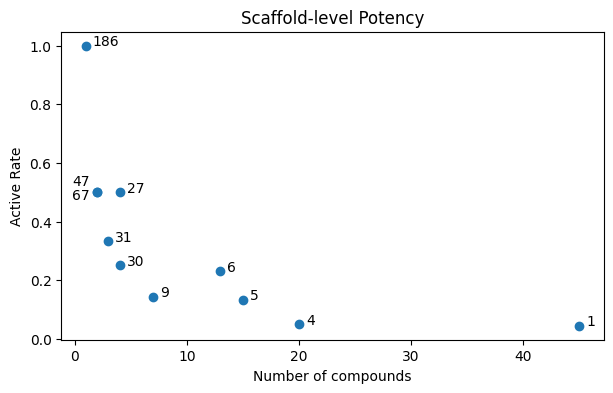

In [58]:
# Scaffold-level potency
data = scaffold_groups[scaffold_groups["n_active"] >= 1]

plt.figure(figsize=(7, 4))

for i, row in data.iterrows():
    offset = (5, 0)
    if row["scaffold_id"] == 47:
        offset = (-18, 5)
    if row["scaffold_id"] == 67:
        offset = (-18, -5)
    plt.annotate(row["scaffold_id"], (row["n_compounds"], row["active_rate"]),xytext=offset,textcoords="offset points")

plt.scatter(data["n_compounds"], data["active_rate"])

plt.xlabel("Number of compounds")
plt.ylabel("Active Rate")
plt.title("Scaffold-level Potency")
plt.show()

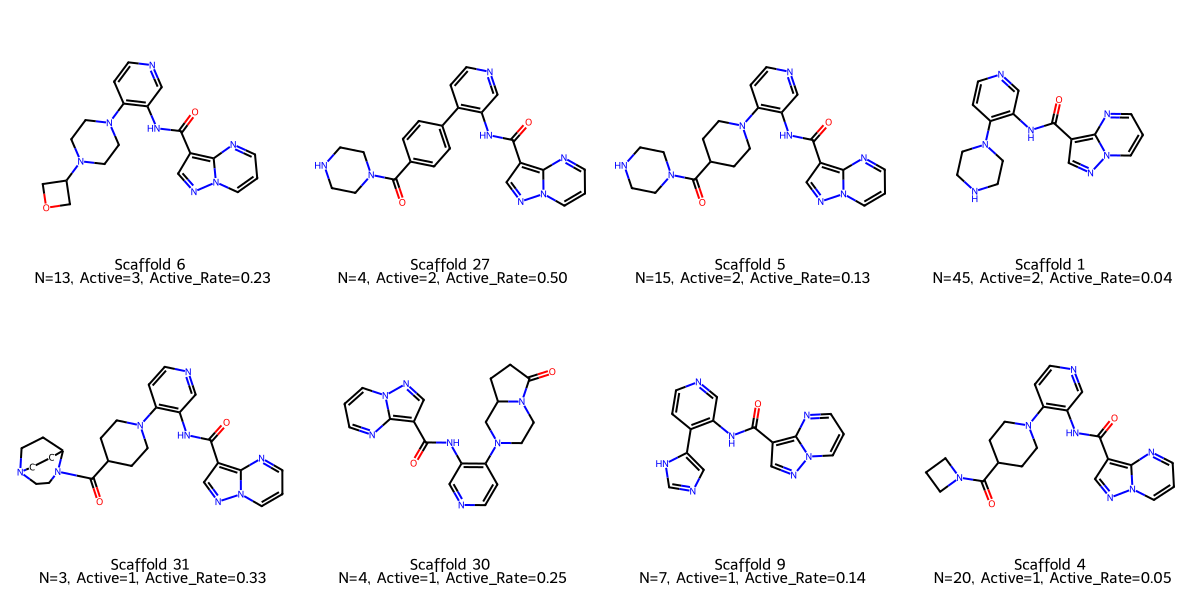

In [59]:
# Draw promising scaffolds
from rdkit.Chem import Draw
from PIL import Image
import io

mols = [Chem.MolFromSmiles(smiles) for smiles in promising_scaffolds["scaffold"]]
labels = [
    f"Scaffold {i}\n N={n}, Active={a}, Active_Rate={r:.2f}"
    for i, n, a, r in zip(
        promising_scaffolds["scaffold_id"],
        promising_scaffolds["n_compounds"],
        promising_scaffolds["n_active"],
        promising_scaffolds["active_rate"]
        )
]
img = Draw.MolsToGridImage(mols, legends = labels, molsPerRow=4, subImgSize=(300, 300), useSVG=False)
Image.open(io.BytesIO(img.data)).save("/content/drive/MyDrive/Axiom/figures/02.top5_scaffolds.png")
display(img)

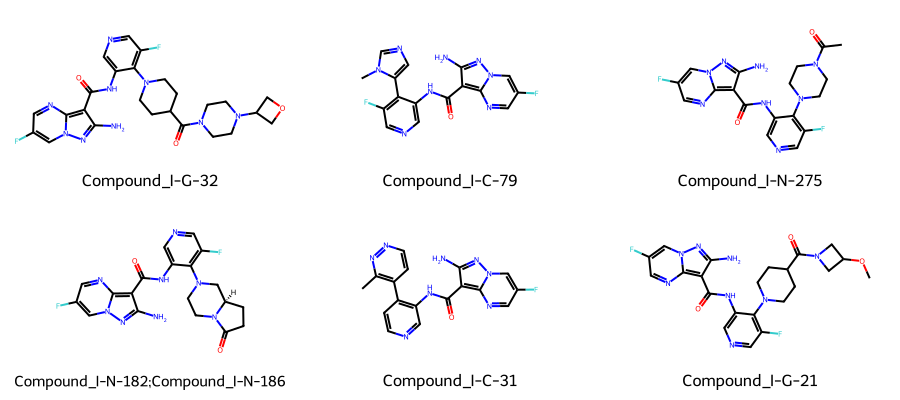

In [60]:
benchmark_smiles = []
for b in benchmark_names:
    benchmark_smiles.append(df_log[df_log["name"] == b]["smiles"].iloc[0])

labels = benchmark_names
mols = [Chem.MolFromSmiles(s) for s in benchmark_smiles]
img = Draw.MolsToGridImage(mols, legends = labels, molsPerRow=3, subImgSize=(300, 200), useSVG=False)
display(img)

In [61]:
for b in benchmark_names:
  b_scaffold = df_log[df_log["name"] == b]["scaffold"].iloc[0]
  b_scaffold_id = scaffold_groups[scaffold_groups["scaffold"] == b_scaffold]["scaffold_id"].iloc[0]
  print(b, "\nscaffod_id: ", b_scaffold_id)

Compound_I-G-32 
scaffod_id:  47
Compound_I-C-79 
scaffod_id:  9
Compound_I-N-275 
scaffod_id:  1
Compound_I-N-182;Compound_I-N-186 
scaffod_id:  30
Compound_I-C-31 
scaffod_id:  67
Compound_I-G-21 
scaffod_id:  4


## 5. SAR Analysis for Representative Scaffolds

In [62]:
# Gartisertib (M4344) in scaffold_47
scaffold_47 = df_log[df_log["scaffold"] == scaffold_groups["scaffold"].iloc[46]]
scaffold_47

,name,smiles,atr_binding_potency,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,...,ros_ld20,ros_ld50,halos_ld20,halos_ld50,n_censored,ld20_cts,ld50_cts,active,tox_score,scaffold
482,Compound_I-G-32,NC1=NN2C=C(F)C=NC2=C1C(=O)NC1=C(N2CCC(CC2)C(=O...,< 20 nM,1.152100,2.010771,0.354005,1.449879,1.913710,3.230576,1.410762,...,1.230104,2.534441,0.407251,1.261289,0,0.574276,0.460792,1,0.574276,O=C(Nc1cnccc1N1CCC(C(=O)N2CCN(C3COC3)CC2)CC1)c...
537,Compound_I-G-92,CC1(COC1)N1CCN(CC1)C(=O)C1CCN(CC1)C1=C(NC(=O)C...,Inactive,1.021283,1.877800,-0.098717,0.782658,1.679486,2.742872,1.096272,...,0.597417,1.937351,1.068356,1.552162,0,0.077649,0.117402,0,0.077649,O=C(Nc1cnccc1N1CCC(C(=O)N2CCN(C3COC3)CC2)CC1)c...


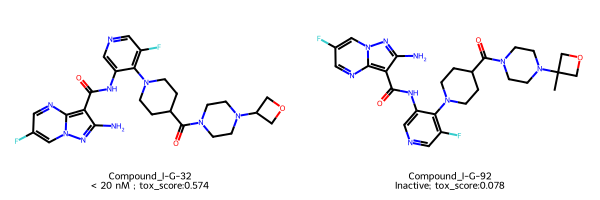

In [63]:
from rdkit import Chem
from rdkit.Chem import Draw

comp = ["Compound_I-G-32",
        "Compound_I-G-92"
       ]

comp_smiles = []
labels = []

for c in comp:
    row = df_log[df_log["name"] == c].iloc[0]
    comp_smiles.append(row["smiles"])
    labels.append(f"{row["name"]}\n{row["atr_binding_potency"]}; tox_score:{row["tox_score"].round(3)}")

mols = [Chem.MolFromSmiles(s) for s in comp_smiles]

img = Draw.MolsToGridImage(mols, legends = labels, molsPerRow=2, subImgSize=(300, 200), useSVG=False)
display(img)

### 5.1 Scaffold_9

In [64]:
scaffold_9 = df_log[df_log["scaffold"] == scaffold_groups["scaffold"].iloc[8]]
scaffold_9

,name,smiles,atr_binding_potency,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,...,ros_ld20,ros_ld50,halos_ld20,halos_ld50,n_censored,ld20_cts,ld50_cts,active,tox_score,scaffold
424,Compound_I-C-56,CN1C=NC=C1C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=N...,Inactive,1.130494,1.966550,0.226977,1.192264,2.376690,3.935684,1.590614,...,0.995071,1.940080,1.316109,1.791446,0,0.481955,0.347215,0,0.481955,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12
445,Compound_I-C-77,CN1C(C)=NC=C1C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)...,Inactive,1.052909,1.852403,0.268548,1.156578,2.392676,4.000000,1.544377,...,1.067838,2.103337,1.118498,1.703665,1,0.462889,0.387893,0,0.462889,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12
446,Compound_I-C-78,CN1C=NC(C)=C1C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)...,Inactive,1.144060,1.938675,0.225338,1.207438,2.568941,4.000000,1.622113,...,1.063055,2.050704,1.216101,1.789194,1,0.498672,0.382521,0,0.498672,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12
447,Compound_I-C-79,CN1C=NC=C1C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=N...,< 20 nM,1.586221,2.383616,0.820684,1.857198,3.712300,4.000000,2.776107,...,2.141425,3.209342,1.321556,1.941947,2,0.942305,0.836515,1,0.942305,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12
448,Compound_I-C-80,CCN1C=NC=C1C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=...,Inactive,1.157767,1.947087,0.295964,1.265664,2.314367,3.888936,1.627212,...,1.077165,2.004307,1.253290,1.778979,0,0.522527,0.380889,0,0.522527,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12
449,Compound_I-C-81,COC1=CN=CC(NC(=O)C2=C3N=CC(F)=CN3N=C2N)=C1C1=C...,Inactive,1.087096,1.947928,0.232213,1.254953,2.703361,4.000000,1.555868,...,0.976270,1.962340,1.444840,1.953881,1,0.478759,0.381397,0,0.478759,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12
451,Compound_I-C-83,COCCN1C=NC=C1C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)...,Inactive,1.195175,2.044853,0.308881,1.325374,2.483295,4.000000,1.708202,...,1.042708,2.078429,1.345766,1.887834,1,0.522152,0.435641,0,0.522152,O=C(Nc1cnccc1-c1cnc[nH]1)c1cnn2cccnc12


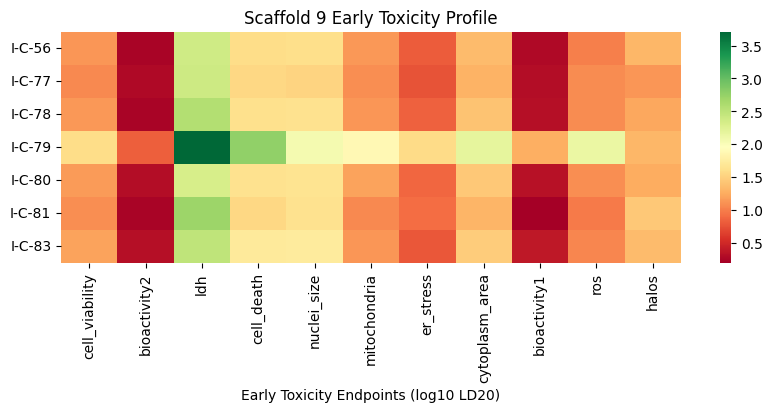

In [65]:
# Early toxicity profile heatmap of Scaffold 9 compounds
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

sns.heatmap(
    scaffold_9[ld20_columns],
    xticklabels = [x.replace("_ld20", "") for x in ld20_columns],
    yticklabels = scaffold_9["name"].str.replace("Compound_", ""),
    cmap="RdYlGn"
)

plt.xlabel("Early Toxicity Endpoints (log10 LD20)")
plt.title("Scaffold 9 Early Toxicity Profile")

plt.show()


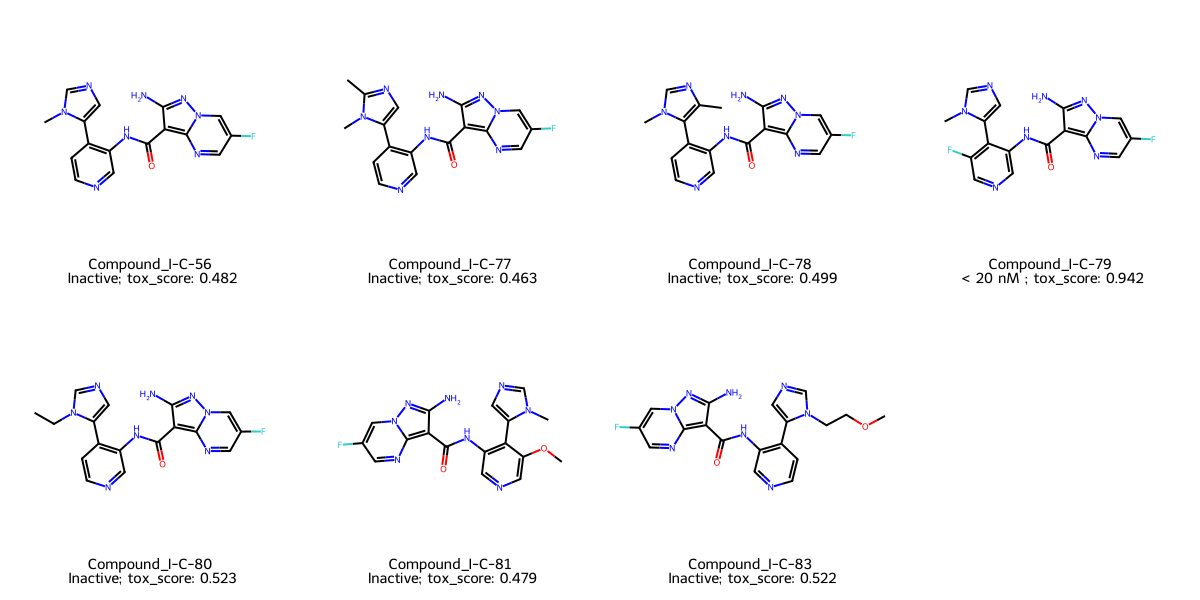

In [66]:
from rdkit import Chem
import matplotlib.pyplot as plt

mols = [Chem.MolFromSmiles(smiles) for smiles in scaffold_9["smiles"]]
labels = [f"{i}\n {a}; tox_score: {t}"
    for i, a, t in zip(
        scaffold_9["name"],
        scaffold_9["atr_binding_potency"],
        scaffold_9["tox_score"].round(3)
    )
]

img = Draw.MolsToGridImage(mols, legends = labels, molsPerRow=4, subImgSize=(300, 300), useSVG=False)
display(img)

- I-C-79 (Tuvusertib) vs. I-C-56/I-C-81: the fluorine substitution on the pyridine ring was associated with increased ATR activity and a more favorable exploratory early toxicity profile in this dataset. This is an association, not proof that fluorination itself caused improved safety.


### 5.2 Scaffold_1

In [67]:
scaffold_1 = df_log[df_log["scaffold"] == scaffold_groups["scaffold"].iloc[0]]
scaffold_1

,name,smiles,atr_binding_potency,cell_viability_ld20,cell_viability_ld50,bioactivity2_ld20,bioactivity2_ld50,ldh_ld20,ldh_ld50,cell_death_ld20,...,ros_ld20,ros_ld50,halos_ld20,halos_ld50,n_censored,ld20_cts,ld50_cts,active,tox_score,scaffold
2,Compound_I-N-3,CN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=...,Inactive,1.324332,2.391607,0.275077,1.598693,2.597246,4.000000,1.550583,...,1.023727,2.241115,0.842765,1.660068,2,0.517383,0.701373,0,0.517383,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
3,Compound_I-N-4,CC(C)N1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2...,Inactive,1.187237,2.131031,0.216526,1.340297,2.647051,4.000000,1.606578,...,1.116153,2.378322,0.799496,1.651986,1,0.483121,0.605773,0,0.483121,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
12,Compound_I-N-14,CN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(Cl)=CN3N=C2N)C...,Inactive,1.229657,2.143460,0.354444,1.484843,2.234291,3.670659,1.596375,...,1.124199,2.261297,0.969963,1.816222,1,0.562178,0.643272,0,0.562178,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
13,Compound_I-N-15,CN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C=...,Inactive,1.333205,2.416653,0.334554,1.609308,2.529519,4.000000,1.672374,...,1.045883,2.306745,1.005504,1.879379,3,0.548814,0.731199,0,0.548814,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
15,Compound_I-N-17,CCN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N)C...,Inactive,1.283651,2.260320,0.290499,1.513426,2.936547,4.000000,1.673690,...,1.177811,2.470191,0.783926,1.705664,1,0.561430,0.678527,0,0.561430,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
18,Compound_I-N-20,NC1=NN2C=C(F)C=NC2=C1C(=O)NC1=C(C=CN=C1)N1CCN(...,Inactive,1.230011,2.042444,0.279424,1.378193,2.536721,4.000000,1.573019,...,1.213621,2.432578,0.920559,1.640013,1,0.521852,0.468519,0,0.521852,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
20,Compound_I-N-22,COCCN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(F)=CN3N=C2N...,Inactive,1.328690,2.366487,0.200354,1.457325,3.174616,4.000000,1.726043,...,1.282820,3.055573,0.888057,1.749946,3,0.555074,0.751793,0,0.555074,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
32,Compound_I-N-34,CC(C)(C)N1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(Cl)=CN3...,Inactive,1.131803,1.952452,0.138493,1.216271,2.097208,3.396227,1.391087,...,0.983035,2.094647,0.800517,1.457375,0,0.424243,0.395975,0,0.424243,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
37,Compound_I-N-39,CC(C)N1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(Cl)=CN3N=C...,Inactive,1.088583,1.927720,0.166870,1.231582,2.149937,3.528070,1.439132,...,0.986143,2.124182,0.782703,1.439300,0,0.421044,0.417255,0,0.421044,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12
39,Compound_I-N-41,CN1CCN(CC1)C1=C(NC(=O)C2=C3N=CC(Cl)=CN3N=C2N)C...,Inactive,1.208695,2.029286,0.364809,1.445660,2.039504,3.304549,1.493389,...,1.084571,2.137015,0.888179,1.535117,0,0.553910,0.557809,0,0.553910,O=C(Nc1cnccc1N1CCNCC1)c1cnn2cccnc12


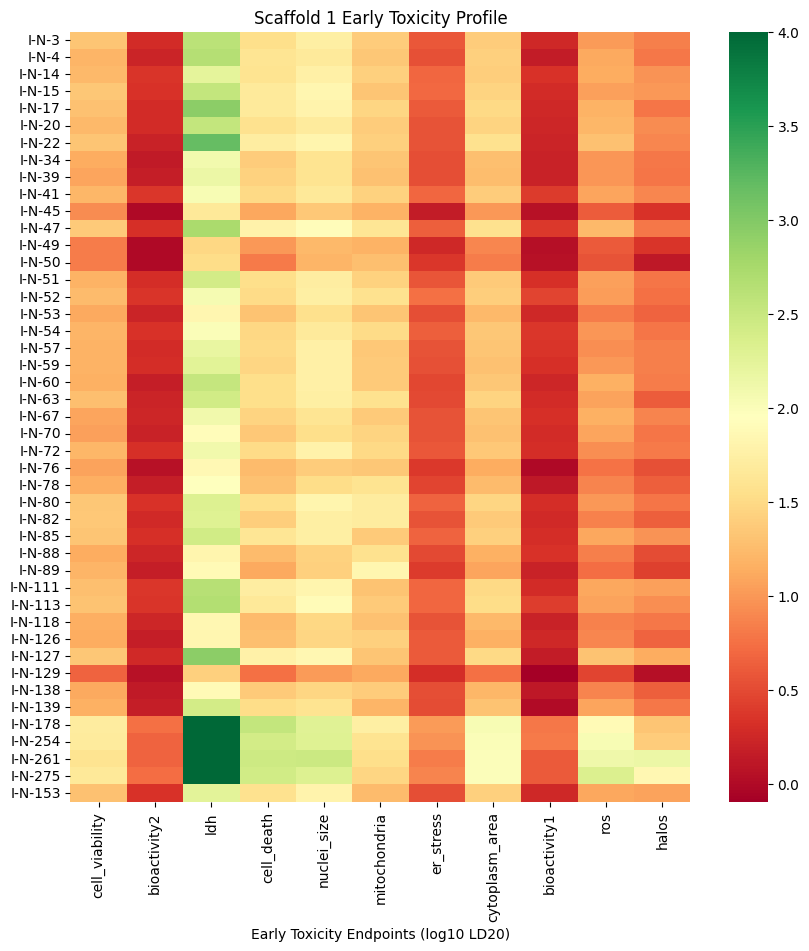

In [68]:
# Toxicity profile heatmap of Scaffold 1 compounds
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

sns.heatmap(
    scaffold_1[ld20_columns],
    xticklabels = [x.replace("_ld20", "") for x in ld20_columns],
    yticklabels = scaffold_1["name"].str.replace("Compound_", ""),
    cmap="RdYlGn"
)

plt.xlabel("Early Toxicity Endpoints (log10 LD20)")
plt.title("Scaffold 1 Early Toxicity Profile")

plt.show()

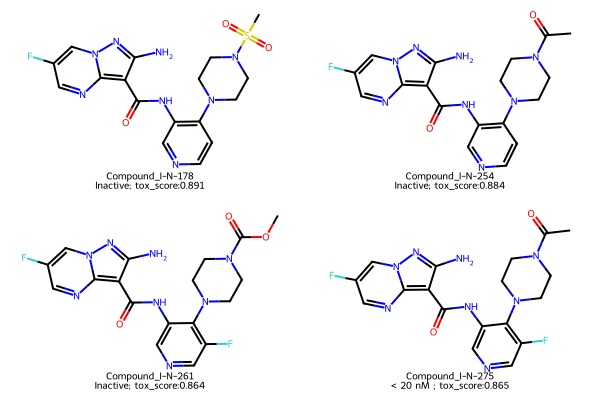

In [69]:
from rdkit import Chem
from rdkit.Chem import Draw

comp = ["Compound_I-N-178",
        "Compound_I-N-254",
        "Compound_I-N-261",
        "Compound_I-N-275"
       ]

comp_smiles = []
labels = []

for c in comp:
    row = df_log[df_log["name"] == c].iloc[0]
    comp_smiles.append(row["smiles"])
    labels.append(f"{row["name"]}\n{row["atr_binding_potency"]}; tox_score:{row["tox_score"].round(3)}")

mols = [Chem.MolFromSmiles(s) for s in comp_smiles]

img = Draw.MolsToGridImage(mols, legends = labels, molsPerRow=2, subImgSize=(300, 200), useSVG=False)
display(img)

- I-N-254 vs. I-N-275: Same as in scaffold 9 analysis, the introduction of a fluorine substituent on the pyridine ring was associated with increased ATR activity while maintaining a favorable exploratory early toxicity profile.
- I-N-261 vs. I-N-275: replacing methyl carbamate with acetamide was associated with increased ATR activity while maintaining a favorable exploratory early toxicity profile.


## 6. R Group Analysis


### 6.1 Active Compound R Group Analysis

In [49]:
# Perform R Group Decomposition
from rdkit import Chem
from rdkit.Chem import rdRGroupDecomposition

rgroups, unmatched = rdRGroupDecomposition.RGroupDecompose([active_mcs_mol], active_mols)

rgroups_df = pd.DataFrame(rgroups)
rgroups_df["name"] = actives["name"].values
rgroups_df["ld20_cts"] = actives["ld20_cts"].values
rgroups_df

,Core,R1,R2,R3,name,ld20_cts
0,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a500>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a730>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a420>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a7a0>,Compound_I-N-1,0.399573
1,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a810>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a880>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a8f0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a960>,Compound_I-N-13,0.382963
2,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1a9d0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1aa40>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1aab0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ab20>,Compound_I-N-58,0.346488
3,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ab90>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ac00>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ac70>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ace0>,Compound_I-N-118,0.392678
4,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ad50>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1adc0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1ae30>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1aea0>,Compound_I-N-166,0.282580
5,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1af10>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1af80>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1aff0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b060>,Compound_I-N-182;Compound_I-N-186,0.759816
6,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b0d0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b140>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b1b0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b220>,Compound_I-N-275,0.865254
7,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b290>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b300>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b370>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b3e0>,Compound_I-C-25,0.122370
8,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b450>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b4c0>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b530>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b5a0>,Compound_I-C-31,0.744259
9,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b610>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b680>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b760>,<rdkit.Chem.rdchem.Mol object at 0x7f2253a1b7d0>,Compound_I-C-43,0.126449


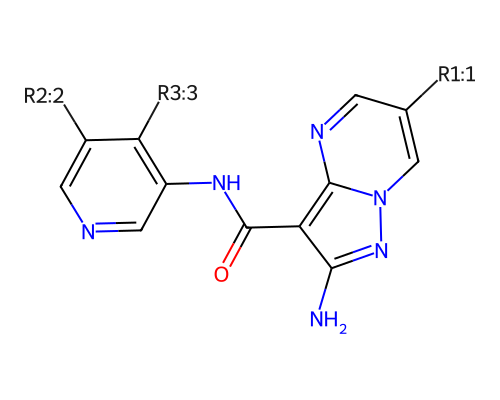

In [50]:
from rdkit.Chem import Draw

display(
    Draw.MolToImage(
        rgroups_df.loc[0, "Core"],
        size=(500, 400)
    )
)

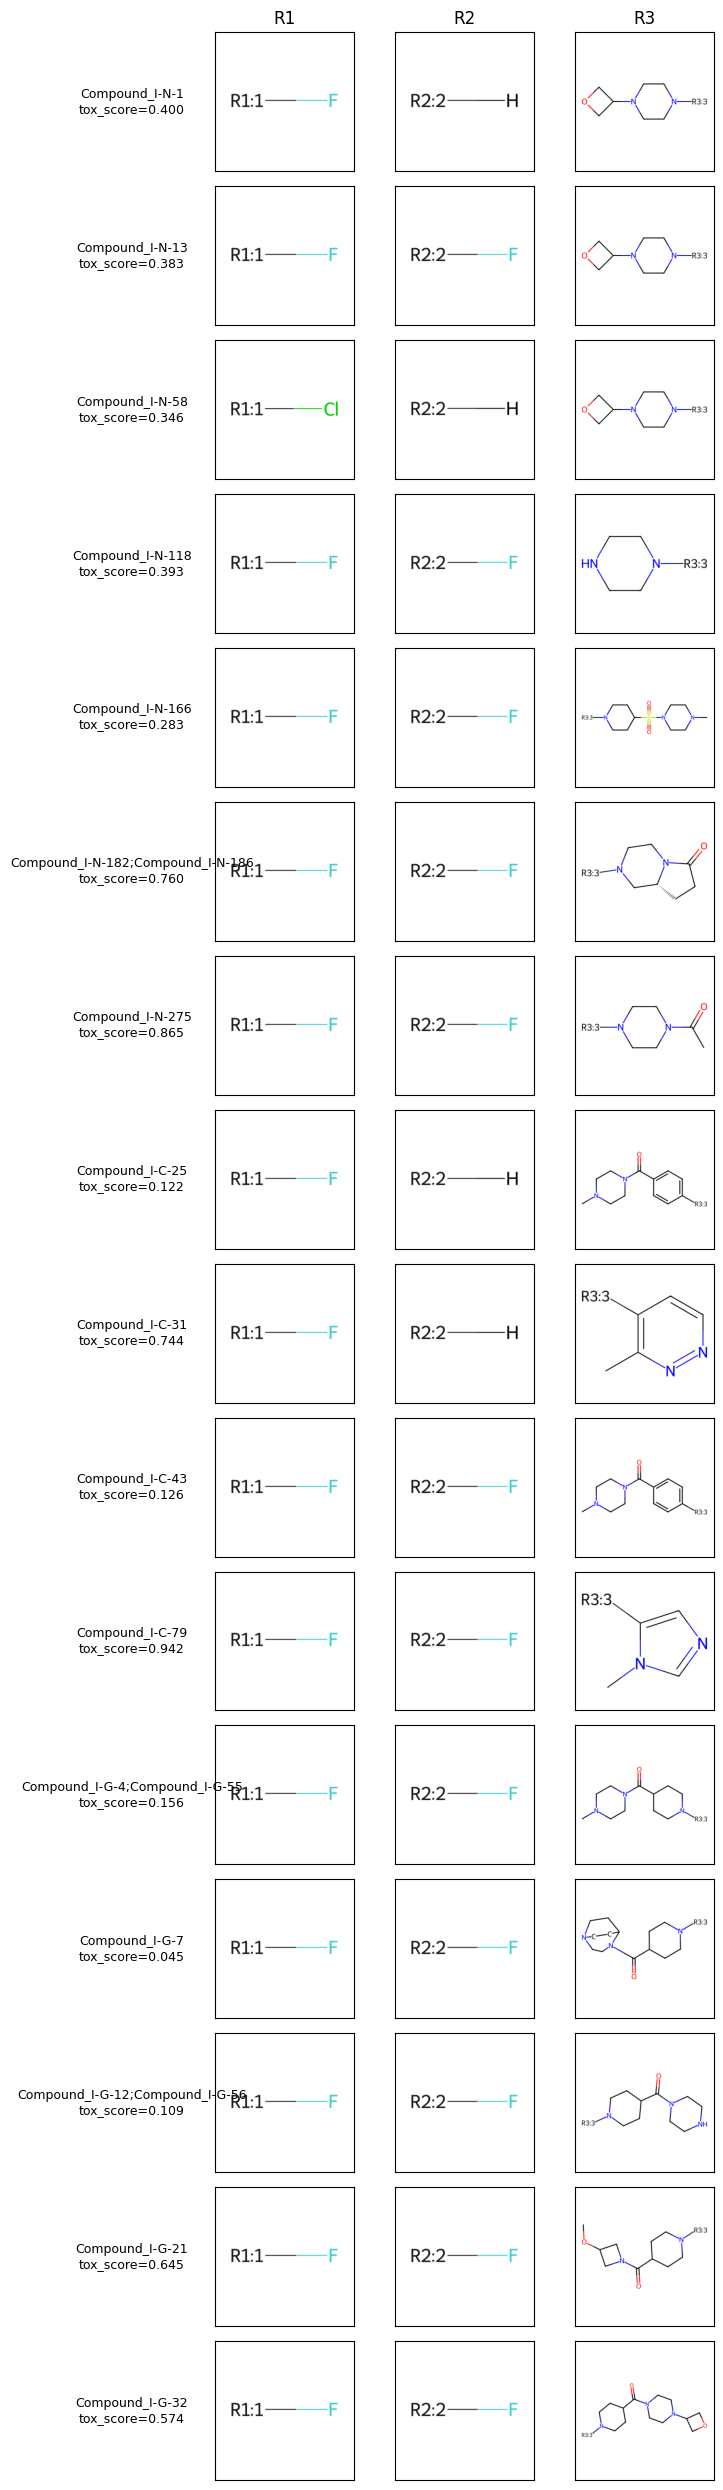

In [51]:
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(rgroups_df), 3, figsize=(8, 25))

for i in range(len(rgroups_df)):
    for j, col in enumerate(["R1", "R2", "R3"]):
        axes[i, j].imshow(Draw.MolToImage(rgroups_df.loc[i, col]))
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

    axes[i, 0].set_ylabel(
        f'{rgroups_df.loc[i, "name"]}\ntox_score={rgroups_df.loc[i, "ld20_cts"]:.3f}',
        rotation=0,
        labelpad=60,
        va="center",
        fontsize=9
    )

for j, col in enumerate(["R1", "R2", "R3"]):
    axes[0, j].set_title(col)

plt.tight_layout()
plt.show()

- Among potent compounds, R1 and R2 are relatively constrained (H/halo), while R3 shows greater structural diversification and substantial variation in toxicity-margin scores.

### 6.2 All Compound SAR Analysis

In [70]:
# Build an R-group decomposition across all compounds that match the active-compound MCS

from rdkit import Chem
from rdkit.Chem import rdRGroupDecomposition
import pandas as pd
import numpy as np

# Remove the known non-matching compound and reset index
df_log_matched = df_log.drop(index=418).reset_index(drop=True)

# R-group decomposition
sar_rgroups, unmatched = rdRGroupDecomposition.RGroupDecompose([active_mcs_mol], mols_uni)
sar_rgroup_df = pd.DataFrame(sar_rgroups)

# Add metadata
meta_cols = ["name", "atr_binding_potency", "ld20_cts", "ld50_cts"]
sar_rgroup_df = sar_rgroup_df.merge(
    df_log_matched[meta_cols],
    left_index=True,
    right_index=True,
    how="left"
)

# Define active compounds
sar_rgroup_df["active"] = sar_rgroup_df["atr_binding_potency"].str.contains("<", na=False)

# R-group columns
rgroup_cols = [c for c in sar_rgroup_df.columns if c.startswith("R")]

print(f"Compounds matching SAR core: {len(mols_uni)}")
print(f"Successfully decomposed: {len(sar_rgroup_df)}")
print(f"R-group columns: {rgroup_cols}")
print(f"Unmatched after R-group decomposition: {len(unmatched)}")

Compounds matching SAR core: 552
Successfully decomposed: 552
R-group columns: ['R1', 'R2', 'R3', 'R4']
Unmatched after R-group decomposition: 0


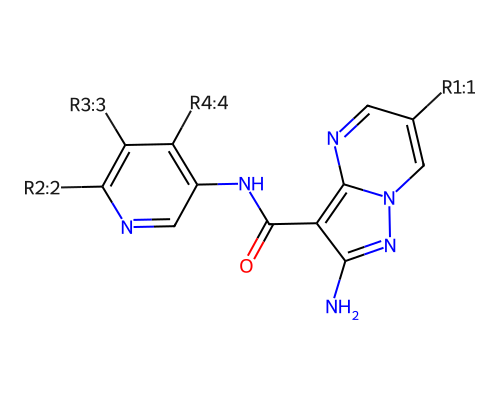

In [87]:
from rdkit.Chem import Draw

display(
    Draw.MolToImage(
        sar_rgroup_df.loc[0, "Core"],
        size=(500, 400)
    )
)

In [71]:
# SAR MMP Analysis

def norm(x):
    return "[NONE]" if x is None or pd.isna(x) else Chem.MolToSmiles(x, canonical=True)

pairs = []

for i in range(len(sar_rgroup_df)):
    for j in range(i + 1, len(sar_rgroup_df)):
        a, b = sar_rgroup_df.iloc[i], sar_rgroup_df.iloc[j]

        # R-groups differing between the two compounds
        diffs = [r for r in rgroup_cols if norm(a[r]) != norm(b[r])]

        # Exactly one R-group difference + opposite activity
        if len(diffs) != 1 or a["active"] == b["active"]:
            continue

        r = diffs[0]
        active, inactive = (a, b) if a["active"] else (b, a)

        pairs.append({
            "inactive_compound": inactive["name"],
            "active_compound": active["name"],
            "changed_R_group": r,
            "inactive_R_group": norm(inactive[r]),
            "active_R_group": norm(active[r]),
            "delta_LD20_CTS": active["ld20_cts"] - inactive["ld20_cts"],
            "delta_LD50_CTS": active["ld50_cts"] - inactive["ld50_cts"],
        })

matched_pair_df = pd.DataFrame(pairs)

matched_pair_df

,inactive_compound,active_compound,changed_R_group,inactive_R_group,active_R_group,delta_LD20_CTS,delta_LD50_CTS
0,Compound_I-N-3,Compound_I-N-1,R4,CN1CCN([*:4])CC1,C1OCC1N1CCN([*:4])CC1,-0.117810,-0.091589
1,Compound_I-N-4,Compound_I-N-1,R4,CC(C)N1CCN([*:4])CC1,C1OCC1N1CCN([*:4])CC1,-0.083548,0.004011
2,Compound_I-N-7,Compound_I-N-1,R4,c1cn([*:4])cn1,C1OCC1N1CCN([*:4])CC1,-0.353111,-0.029886
3,Compound_I-N-8,Compound_I-N-1,R4,CNCCc1cnn([*:4])c1,C1OCC1N1CCN([*:4])CC1,0.108098,0.246198
4,Compound_I-N-9,Compound_I-N-1,R4,CN(C)CCc1cnn([*:4])c1,C1OCC1N1CCN([*:4])CC1,0.070716,0.262893
...,...,...,...,...,...,...,...
2468,Compound_I-G-99,Compound_I-G-32,R4,CO[C@H]1CCN(C(=O)C2CCN([*:4])CC2)C1,O=C(C1CCN([*:4])CC1)N1CCN(C2COC2)CC1,-0.007583,-0.112635
2469,Compound_I-N-153,Compound_I-G-32,R4,CN(C)CC(=O)N1CCN([*:4])CC1,O=C(C1CCN([*:4])CC1)N1CCN(C2COC2)CC1,0.082823,-0.179706
2470,Compound_I-N-242,Compound_I-G-32,R4,Cc1ncnn1[*:4],O=C(C1CCN([*:4])CC1)N1CCN(C2COC2)CC1,-0.247001,-0.372555
2471,Compound_I-G-28,Compound_I-G-32,R4,O=C(C1CCN([*:4])CC1)N1CCNC2(CC2)C1,O=C(C1CCN([*:4])CC1)N1CCN(C2COC2)CC1,0.441418,0.252581


In [102]:
# Find recurring structural transformations
sar_summary = (
    matched_pair_df.groupby(
        ["changed_R_group", "inactive_R_group", "active_R_group"],
        dropna=False
    )
    .agg(
        n_pairs=("inactive_compound", "size"),
        median_delta_LD20_CTS=("delta_LD20_CTS", "median"),
        median_delta_LD50_CTS=("delta_LD50_CTS", "median")
    )
    .reset_index()
)

selected_sar_summary = (
    sar_summary[
      (sar_summary["n_pairs"] >= 3)
    ]
    .sort_values(
        "n_pairs",
        ascending=False
    )
)
print(len(sar_summary), len(selected_sar_summary))
selected_sar_summary

2357 7


,changed_R_group,inactive_R_group,active_R_group,n_pairs,median_delta_LD20_CTS,median_delta_LD50_CTS
11,R3,Cl[*:3],F[*:3],5,-0.004785,0.044269
14,R3,[H][*:3],F[*:3],5,0.003909,-0.025327
4,R1,Cl[*:1],F[*:1],3,0.004414,0.093309
251,R4,C1OCC1N1CCC([*:4])CC1,C1OCC1N1CCN([*:4])CC1,3,-0.110625,-0.086778
768,R4,CN1CCC(O[*:4])CC1,C1OCC1N1CCN([*:4])CC1,3,-0.060865,0.047587
1024,R4,CN1CCN([*:4])CC1,C1OCC1N1CCN([*:4])CC1,3,-0.136376,-0.091589
1241,R4,COCCN1CCN([*:4])CC1,C1OCC1N1CCN([*:4])CC1,3,-0.155501,-0.142009


In [103]:
def to_mol(x):
    if isinstance(x, Chem.Mol):
        return x
    if x is None or pd.isna(x):
        return None
    return Chem.MolFromSmiles(x)

selected_sar_summary["inactive_R_group"] = (
    selected_sar_summary["inactive_R_group"].apply(to_mol)
)

selected_sar_summary["active_R_group"] = (
    selected_sar_summary["active_R_group"].apply(to_mol)
)

[03:39:53] WARNING: not removing hydrogen atom with dummy atom neighbors


,changed_R_group,inactive_R_group,active_R_group,n_pairs,median_delta_LD20_CTS,median_delta_LD50_CTS
11,R3,,,5,-0.004785,0.044269
14,R3,,,5,0.003909,-0.025327
4,R1,,,3,0.004414,0.093309
251,R4,,,3,-0.110625,-0.086778
768,R4,,,3,-0.060865,0.047587
1024,R4,,,3,-0.136376,-0.091589
1241,R4,,,3,-0.155501,-0.142009

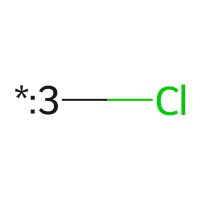
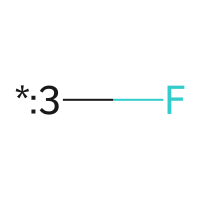
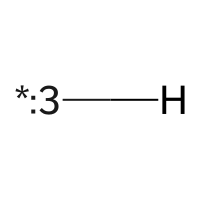
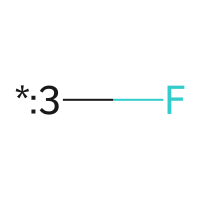
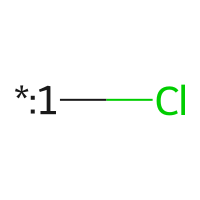
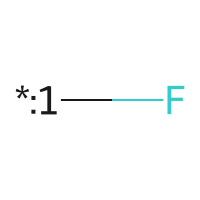
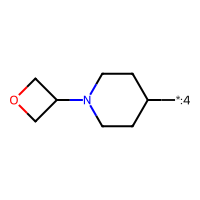
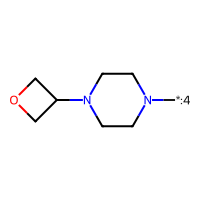
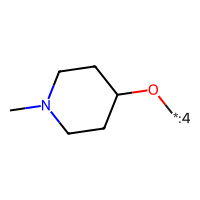
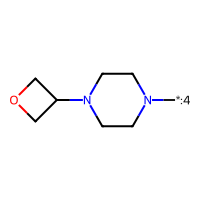
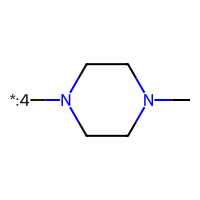
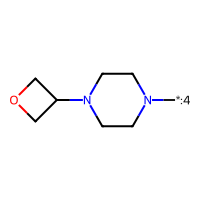
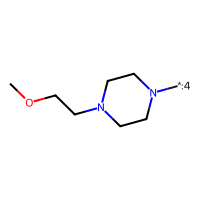
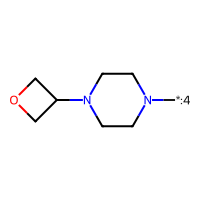

In [104]:
from rdkit.Chem import PandasTools

PandasTools.RenderImagesInAllDataFrames(images=True)

display(
    selected_sar_summary[
        [
            "changed_R_group",
            "inactive_R_group",
            "active_R_group",
            "n_pairs",
            "median_delta_LD20_CTS",
            "median_delta_LD50_CTS"
        ]
    ]
)

### 6.3 All Compound STR Analysis

In [72]:
# STR MMP Analysis

pairs2 = []

for i in range(len(sar_rgroup_df)):
    for j in range(i + 1, len(sar_rgroup_df)):

        a = sar_rgroup_df.iloc[i]
        b = sar_rgroup_df.iloc[j]

        # Identify R-groups that differ
        diffs = [r for r in rgroup_cols if norm(a[r]) != norm(b[r])]

        # Keep matched pairs differing at exactly one R-group
        if len(diffs) != 1:
            continue

        r = diffs[0]

        pairs2.append({
            "compound_1": a["name"],
            "compound_2": b["name"],
            "changed_R_group": r,

            "R_group_1": norm(a[r]),
            "R_group_2": norm(b[r]),

            "LD20_CTS_1": a["ld20_cts"],
            "LD20_CTS_2": b["ld20_cts"],
            "delta_LD20_CTS": b["ld20_cts"] - a["ld20_cts"],

            "LD50_CTS_1": a["ld50_cts"],
            "LD50_CTS_2": b["ld50_cts"],
            "delta_LD50_CTS": b["ld50_cts"] - a["ld50_cts"],
        })

structure_tox_df = pd.DataFrame(pairs2)

structure_tox_df

,compound_1,compound_2,changed_R_group,R_group_1,R_group_2,LD20_CTS_1,LD20_CTS_2,delta_LD20_CTS,LD50_CTS_1,LD50_CTS_2,delta_LD50_CTS
0,Compound_I-N-1,Compound_I-N-3,R4,C1OCC1N1CCN([*:4])CC1,CN1CCN([*:4])CC1,0.399573,0.517383,0.117810,0.609784,0.701373,0.091589
1,Compound_I-N-1,Compound_I-N-4,R4,C1OCC1N1CCN([*:4])CC1,CC(C)N1CCN([*:4])CC1,0.399573,0.483121,0.083548,0.609784,0.605773,-0.004011
2,Compound_I-N-1,Compound_I-N-7,R4,C1OCC1N1CCN([*:4])CC1,c1cn([*:4])cn1,0.399573,0.752684,0.353111,0.609784,0.639670,0.029886
3,Compound_I-N-1,Compound_I-N-8,R4,C1OCC1N1CCN([*:4])CC1,CNCCc1cnn([*:4])c1,0.399573,0.291475,-0.108098,0.609784,0.363586,-0.246198
4,Compound_I-N-1,Compound_I-N-9,R4,C1OCC1N1CCN([*:4])CC1,CN(C)CCc1cnn([*:4])c1,0.399573,0.328857,-0.070716,0.609784,0.346891,-0.262893
...,...,...,...,...,...,...,...,...,...,...,...
38421,Compound_I-N-242,Compound_I-N-114,R4,Cc1ncnn1[*:4],CN1CCN2CCN([*:4])CC2C1,0.821277,0.287199,-0.534078,0.833347,0.504181,-0.329167
38422,Compound_I-O-79,Compound_I-N-96,R4,C1C[C@]2(C[C@@H](O[*:4])C2)N1,C1CN([*:4])CCC1N1CC2(COC2)C1,0.200322,0.198276,-0.002046,0.311823,0.267009,-0.044814
38423,Compound_I-G-28,Compound_I-N-114,R4,O=C(C1CCN([*:4])CC1)N1CCNC2(CC2)C1,CN1CCN2CCN([*:4])CC2C1,0.132858,0.287199,0.154341,0.208212,0.504181,0.295969
38424,Compound_I-N-6,Compound_I-N-110,R4,CN1CCN2CCN([*:4])CC2C1,C1OCC1N1CCN([*:4])CC1,0.285230,0.412746,0.127516,0.450841,0.489623,0.038782


In [73]:
# Find recurring structural transformations
str_summary = (
    structure_tox_df.groupby(
        ["changed_R_group", "R_group_1", "R_group_2"],
        dropna=False
    )
    .agg(
        n_pairs=("compound_1", "size"),
        median_delta_LD20_CTS=("delta_LD20_CTS", "median"),
        median_delta_LD50_CTS=("delta_LD50_CTS", "median")
    )
)

selected_str_summary = (
    str_summary[
        (str_summary["n_pairs"] >= 3) &
        (str_summary["median_delta_LD20_CTS"] >= 0.2)
    ]
    .sort_values(
        "median_delta_LD20_CTS",
        ascending=False
    )
)
print(len(str_summary), len(selected_str_summary))
selected_str_summary

36767 7


n_pairs  \
changed_R_group R_group_1             R_group_2                  
R4              C1CN2CCC1C(O[*:4])C2  C[*:4]                 3   
                C1OCC1N1CCN([*:4])CC1 CO[*:4]                3   
                CN1CCC(O[*:4])CC1     C[*:4]                 3   
                CN1CCN([*:4])CC1      C[*:4]                 3   
                                      CO[*:4]                5   
                                      CCO[*:4]               3   
                                      C1CCN([*:4])CC1        3   

                                                       median_delta_LD20_CTS  \
changed_R_group R_group_1             R_group_2                                
R4              C1CN2CCC1C(O[*:4])C2  C[*:4]                        0.641752   
                C1OCC1N1CCN([*:4])CC1 CO[*:4]                       0.592114   
                CN1CCC(O[*:4])CC1     C[*:4]                        0.546606   
                CN1CCN([*:4])CC1      C[*:4]                        0.478561   
                                      CO[*:4]                       0.455737   
                                      CCO[*:4]                      0.436670   
                                      C1CCN([*:4])CC1               0.335966   

                                                       median_delta_LD50_CTS  
changed_R_group R_group_1             R_group_2                               
R4              C1CN2CCC1C(O[*:4])C2  C[*:4]                        0.514665  
                C1OCC1N1CCN([*:4])CC1 CO[*:4]                       0.349166  
                CN1CCC(O[*:4])CC1     C[*:4]                        0.371641  
                CN1CCN([*:4])CC1      C[*:4]                        0.230286  
                                      CO[*:4]                       0.269318  
                                      CCO[*:4]                      0.206860  
                                      C1CCN([*:4])CC1               0.012848

In [78]:
print(type(selected_str_summary["R_group_1"].iloc[0]))
print(type(selected_str_summary["R_group_2"].iloc[0]))

<class 'str'>
<class 'str'>


In [83]:
def to_mol(x):
    if x is None or pd.isna(x):
        return None
    if isinstance(x, Chem.Mol):
        return x
    return Chem.MolFromSmiles(x)

selected_str_summary["R_group_1"] = (
    selected_str_summary["R_group_1"].apply(to_mol)
)

selected_str_summary["R_group_2"] = (
    selected_str_summary["R_group_2"].apply(to_mol)
)

,changed_R_group,R_group_1,R_group_2,n_pairs,median_delta_LD20_CTS,median_delta_LD50_CTS
0,R4,,,3,0.641752,0.514665
1,R4,,,3,0.592114,0.349166
2,R4,,,3,0.546606,0.371641
3,R4,,,3,0.478561,0.230286
4,R4,,,5,0.455737,0.269318
5,R4,,,3,0.436670,0.206860
6,R4,,,3,0.335966,0.012848

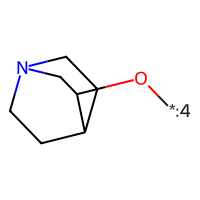
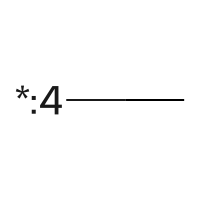
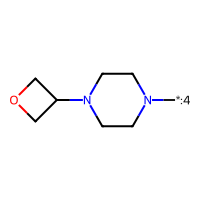
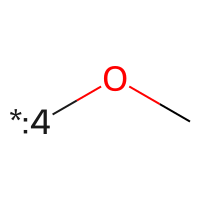
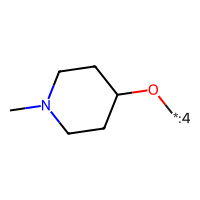
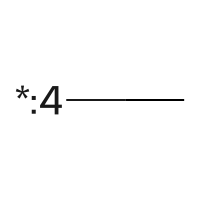
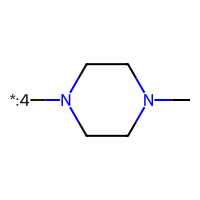
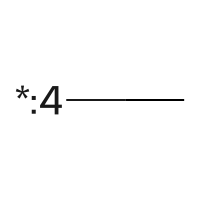
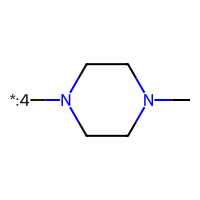
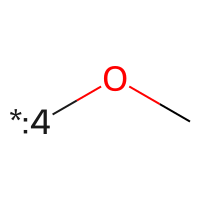
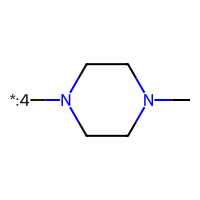
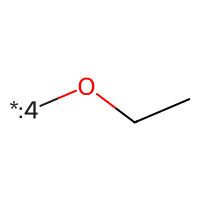
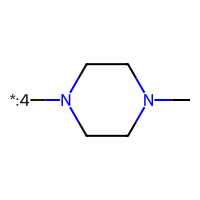
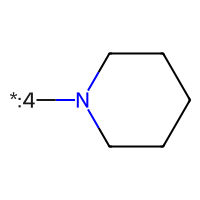

In [84]:
from rdkit.Chem import PandasTools

PandasTools.RenderImagesInAllDataFrames(images=True)

selected_str_summary = selected_str_summary.reset_index()

display(
    selected_str_summary[
        [
            "changed_R_group",
            "R_group_1",
            "R_group_2",
            "n_pairs",
            "median_delta_LD20_CTS",
            "median_delta_LD50_CTS"
        ]
    ]
)

## 6. Lead Prioritization

### Question: Given the analysis and clinical context, which molecules should be prioritized relative to Gartisertib/Tuvusertib?

### Primary criterion: early toxicity (LD20)
The ranking uses composite toxicity score (CTS), LD20_CTS as the primary early toxicity indicator, and LD50_CTS as the secondary overt toxicity indicator.

### Current exploratory priorities
1. **Compound_I-N-275** — strongest combination of sub-20 nM ATR activity and a high early toxicity margin score in this dataset.
2. **Compound_I-C-31** and **Compound_I-N-182 / Compound_I-N-186** — potent ATR activity with favorable early toxicity profiles.

### Clinical benchmarks
- **Compound_I-C-79 / Tuvusertib:** retained as a clinical favorable benchmark.
- **Compound_I-G-32 / Gartisertib:** retained as a clinical toxicity benchmark.

### Important qualification
These rankings are exploratory lead prioritization results, not clinical DILI predictions. The composite toxicity margin score is dataset-derived, built on the observations that several endpoints are highly correlated, and values at 10,000 are assay-range censored. Final prioritization should integrate ATR binding potency, early toxicity, overt toxicity, mechanistic phenotypes, chemical tractability, and more detailed SAR analysis.
